# Create New Angle Types Based on the Data

In [1]:
from openff.toolkit import Molecule, ForceField
from openff.toolkit.typing.engines.smirnoff.parameters import (
    ParameterHandler,
    ParameterType,
    ParameterList,
    BondHandler,
    BondType,
    AngleHandler,
    AngleType,
    ProperTorsionHandler,
    ProperTorsionType,
    ImproperTorsionHandler,
    ImproperTorsionType,
)
from rdkit import Chem
from openff.interchange import Interchange
from collections import Counter, defaultdict
from typing import Iterable
import json
from tqdm import tqdm
import pickle as pkl
from copy import deepcopy
from openff.units import unit as off_unit
from openff.interchange.exceptions import UnassignedTorsionError
from dataclasses import dataclass
from functools import cached_property
from pprint import pprint
from typing import Optional, Literal, Callable
from enum import Enum
from collections import namedtuple
from pathlib import Path
from yammbs.torsion.inputs import QCArchiveTorsionDataset
from yammbs.inputs import QCArchiveDataset
from rdkit.Chem import Draw
from openff.toolkit.topology import Molecule
import numpy as np
from rdkit import Chem
import os
import math
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
from PIL import Image
import io
from openff.toolkit.topology import Molecule, Topology
from openff.toolkit.typing.engines.smirnoff import ForceField
from rdkit import Chem
import json
from functools import partial
from abc import ABC, abstractmethod
import concurrent.futures
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
from datasets import Dataset


_DEGREES = off_unit.degrees
_RADIANS = off_unit.radians
_KCAL_PER_MOL = off_unit.kilocalories_per_mole

SMILES_JSON_PATH = "../data/spice2/smiles_test_train.json"

with open(SMILES_JSON_PATH, "r") as f:
    smiles_data = json.load(f)

# Also get the SMILES after filtering to make sure all types are trained
SMILES_TRAIN_FILTERED_DATASET = Dataset.load_from_disk("../data/spice2/data-filtered-lj-sage-2-2-msm-0-expanded-torsions/data-train")
SMILES_TRAIN_FILTERED = list(SMILES_TRAIN_FILTERED_DATASET["smiles"])

TNETDATA = Path("../benchmarking/torsion_benchmarks/torsionnet_500/input_data/qca-torsion-data.json")
BIARYL_DATA = Path("../benchmarking/torsion_benchmarks/rowley_biaryl/input_data/qca-torsion-data.json")

def get_torsion_smiles(data_path: Path) -> set[str]:
    torsion_data = QCArchiveTorsionDataset.model_validate_json(data_path.read_text())
    return set([t.mapped_smiles for t in torsion_data.qm_torsions])
            
TNET_SMILES = get_torsion_smiles(TNETDATA)
BIARYL_SMILES = get_torsion_smiles(BIARYL_DATA)

INDUSTRY_BENCHMARK_DATA = Path("../benchmarking/industry_benchmark/input_data/filtered-industry-cached.json")

def get_qcdataset_smiles(data_path: Path) -> set[str]:
    dataset = json.loads(data_path.read_text())
    return set([entry["mapped_smiles"] for entry in dataset])

INDUSTRY_BENCHMARK_SMILES = get_qcdataset_smiles(INDUSTRY_BENCHMARK_DATA)

# Get the linear torsions
linear_torsions_ff = ForceField("linear_torsions.offxml")
linear_torsion_parameters = linear_torsions_ff.get_parameter_handler("ProperTorsions").parameters
linear_torsion_smirks = [param.smirks for param in linear_torsion_parameters]

# Get the linear angles
linear_angles_ff = ForceField("openff-2.2.1_lin_ang.offxml")
linear_angle_parameters = linear_angles_ff.get_parameter_handler("Angles").parameters
linear_angle_smirks = [param.smirks for param in linear_angle_parameters]

In [2]:
## Inspect Data

# First, check the overlap between the training data and all the datasets
def check_overlap(smiles_train: list[str], smiles_test: set[str]) -> None:
    train_set = set(smiles_train)
    test_set = set(smiles_test)
    overlap = train_set.intersection(test_set)
    # Print the overlap by number and percentage
    overlap_percentage = len(overlap) / len(train_set) * 100
    print(f"Overlap: {len(overlap)} molecules ({overlap_percentage:.2f}%)")

for dataset_name, smiles_set in [
    ("Test", smiles_data["test"]),
    ("TorsionNet", TNET_SMILES),
    ("Biaryl", BIARYL_SMILES),
    ("Industry Benchmark", INDUSTRY_BENCHMARK_SMILES
     )]:
    print(f"Checking overlap with {dataset_name} dataset...")
    check_overlap(smiles_data["train"], smiles_set)


Checking overlap with Test dataset...
Overlap: 0 molecules (0.00%)
Checking overlap with TorsionNet dataset...
Overlap: 0 molecules (0.00%)
Checking overlap with Biaryl dataset...
Overlap: 0 molecules (0.00%)
Checking overlap with Industry Benchmark dataset...
Overlap: 2 molecules (0.01%)


In [2]:
# Check number of molecules of all net charge in all datasets
def count_molecules_by_net_charge(smiles_list: Iterable[str]) -> Counter:
    net_charge_counter = Counter()
    for smiles in tqdm(smiles_list):
        mol = Molecule.from_mapped_smiles(smiles, allow_undefined_stereo=True)
        rdmol = mol.to_rdkit()
        net_charge = Chem.GetFormalCharge(rdmol)
        net_charge_counter[net_charge] += 1
    return net_charge_counter

def print_net_charge_distribution(smiles_list: Iterable[str], dataset_name: str) -> None:
    net_charge_counter = count_molecules_by_net_charge(smiles_list)
    print(f"Net charge distribution for {dataset_name}:")
    for net_charge, count in sorted(net_charge_counter.items()):
        print(f"  Net charge {net_charge}: {count} molecules")
    print()  # Add a newline for better readability

def print_no_charges(smiles_list: Iterable[str], dataset_name: str, charge: int) -> None:
    """Print the number of molecules which have at least one atom with a specific charge."""
    charge_count = 0
    for smiles in tqdm(smiles_list):
        mol = Molecule.from_mapped_smiles(smiles, allow_undefined_stereo=True)
        rdmol = mol.to_rdkit()
        if any(atom.GetFormalCharge() == charge for atom in rdmol.GetAtoms()):
            charge_count += 1
    print(f"Number of molecules with at least one charge of {charge} in {dataset_name}: {charge_count} of {len(smiles_list)} ({charge_count / len(smiles_list) * 100:.2f}%)")

def print_entirely_neutral(smiles_list: Iterable[str], dataset_name: str) -> None:
    """Print the number of molecules which have no atoms with a charge."""
    neutral_count = 0
    for smiles in tqdm(smiles_list):
        mol = Molecule.from_mapped_smiles(smiles, allow_undefined_stereo=True)
        rdmol = mol.to_rdkit()
        if all(atom.GetFormalCharge() == 0 for atom in rdmol.GetAtoms()):
            neutral_count += 1
    print(f"Number of molecules with no charges in {dataset_name}: {neutral_count} of {len(smiles_list)} ({neutral_count / len(smiles_list) * 100:.2f}%)")

for dataset_name, smiles_set in [
    ("Train", smiles_data["train"]),
    ("Test", smiles_data["test"]),
    ("TorsionNet", TNET_SMILES),
    ("Biaryl", BIARYL_SMILES),
    ("Industry Benchmark", INDUSTRY_BENCHMARK_SMILES)
]:
    print_entirely_neutral(smiles_set, dataset_name)
    # print_no_charges(smiles_set, dataset_name, charge=1)
    # print_no_charges(smiles_set, dataset_name, charge=-1)
    # print_net_charge_distribution(smiles_set, dataset_name)



100%|██████████| 23109/23109 [00:50<00:00, 460.71it/s]


Number of molecules with no charges in Train: 20930 of 23109 (90.57%)


100%|██████████| 1217/1217 [00:02<00:00, 563.22it/s]


Number of molecules with no charges in Test: 1031 of 1217 (84.72%)


100%|██████████| 500/500 [00:00<00:00, 735.82it/s]


Number of molecules with no charges in TorsionNet: 500 of 500 (100.00%)


100%|██████████| 88/88 [00:00<00:00, 845.69it/s]


Number of molecules with no charges in Biaryl: 87 of 88 (98.86%)


100%|██████████| 9662/9662 [00:25<00:00, 375.10it/s]

Number of molecules with no charges in Industry Benchmark: 8506 of 9662 (88.04%)


In [2]:
sage = ForceField("openff-2.0.0.offxml")
mol = Molecule.from_smiles("C1=CC=CC=C1", allow_undefined_stereo=True)
sage.label_molecules(mol.to_topology())

[{'Constraints': ValenceDict(
    {(0, 6): <ConstraintType with smirks: [#1:1]-[*:2]  id: c1  >,
     (1, 7): <ConstraintType with smirks: [#1:1]-[*:2]  id: c1  >,
     (2, 8): <ConstraintType with smirks: [#1:1]-[*:2]  id: c1  >,
     (3, 9): <ConstraintType with smirks: [#1:1]-[*:2]  id: c1  >,
     (4, 10): <ConstraintType with smirks: [#1:1]-[*:2]  id: c1  >,
     (5, 11): <ConstraintType with smirks: [#1:1]-[*:2]  id: c1  >}),
  'Bonds': ValenceDict(
    {(0,
      1): <BondType with smirks: [#6X3:1]:[#6X3:2]  id: b5  length: 1.387193227181 angstrom  k: 721.5704889544 kilocalorie / angstrom ** 2 / mole  >,
     (0,
      5): <BondType with smirks: [#6X3:1]:[#6X3:2]  id: b5  length: 1.387193227181 angstrom  k: 721.5704889544 kilocalorie / angstrom ** 2 / mole  >,
     (0,
      6): <BondType with smirks: [#6X3:1]-[#1:2]  id: b85  length: 1.085358495916 angstrom  k: 794.5091579238 kilocalorie / angstrom ** 2 / mole  >,
     (1,
      2): <BondType with smirks: [#6X3:1]:[#6X3:2]  id:

In [3]:
interchange = Interchange.from_smirnoff(sage, topology=mol.to_topology())

In [8]:
charges = list(interchange.topology.molecules)[0]._partial_charges

In [10]:
[0, 0 ]* off_unit.elementary_charge

Magnitude,[0 0]
Units,elementary_charge


In [9]:
charges

Magnitude,[-0.1301600026587645 -0.1300999956826369 -0.1300999956826369 -0.1300999956826369 -0.1300999956826369 -0.1300999956826369 0.13010999684532484 0.13010999684532484 0.13010999684532484 0.13010999684532484 0.13010999684532484 0.13010999684532484]
Units,elementary_charge


In [203]:
[a.molecule_atom_index for a in list(mol.impropers)[4]]

[4, 3, 9, 2]

In [196]:
mol.generate_conformers(n_conformers=1)
vis = mol.visualize(backend="nglview")
vis.add_label(label_type="atomindex", color="black", attachment="middle-center")
vis

NGLWidget()

In [2]:
GetAtomSmirksFn = Callable[[int, int, Chem.Mol], str]
GetBondsSmirksFn = Callable[[tuple[int, int], bool, Chem.Mol], str]
SpecificityLevel = namedtuple("SpecificityLevel", ["name", "get_atom_smirks", "get_bond_smirks"])

def get_atom_descriptors(at_idx: int, mol: Chem.Mol) -> dict[str, str]:
    """Generate SMRIKS-ready descriptors for an atom in the molecule."""

    # Figure out if the atom is in a ring of size 3 - 8. If larger than 8 (e.g. macrocycle) treat
    # it as not being in a ring.
    ring_sizes = []
    for ring in mol.GetRingInfo().AtomRings():
        if at_idx in ring:
            ring_size = len(ring)
            if 3 <= ring_size <= 8:
                ring_sizes.append(ring_size)

    descriptors = {
        "atomic_num": f"#{mol.GetAtomWithIdx(at_idx).GetAtomicNum()}",
        "degree": f"X{mol.GetAtomWithIdx(at_idx).GetDegree()}",
        "charge": mol.GetAtomWithIdx(at_idx).GetFormalCharge(),
        "ring_size": f";r{min(ring_sizes)}" if ring_sizes else ";!r3;!r4;!r5;!r6;!r7;!r8",
        "aromaticity": ";a" if mol.GetAtomWithIdx(at_idx).GetIsAromatic() else ";A"
    }

    return descriptors

def get_bond_descriptors(atom_idxs: tuple[int, int], mol: Chem.Mol) -> dict[str, str]:
    """
    Get the bond type between two atoms in the molecule.
    Returns a string representation of the bond type.
    """
    bond = mol.GetBondBetweenAtoms(*atom_idxs)
    if bond is None:
        raise ValueError(f"No bond found between atoms {atom_idxs} in the molecule.")

    # Get the bond order description
    TYPE_TO_SMARTS = {Chem.BondType.SINGLE: "-",
                      Chem.BondType.DOUBLE: "=",
                      Chem.BondType.TRIPLE: "#",
                      Chem.BondType.AROMATIC: ":"}

    bond_smarts = TYPE_TO_SMARTS.get(bond.GetBondType(), "~")

    ring_smarts = ";@" if bond.IsInRing() else ";!@"

    descriptors = {"bond_smarts": bond_smarts,
                   "ring_smarts": ring_smarts }

    return descriptors

def get_atom_smirks_standard(at_idx: int, at_id: int, mol: Chem.Mol, terminal_idxs: tuple[int, int]) -> str:
    """
    Generate the SMIRKS representation for an atom in the torsion.
    Standard specificity level.
    """
    ds = get_atom_descriptors(at_idx, mol)
    return f"[{ds['atomic_num']}{ds['degree']}:{at_id + 1}]"

def get_atom_smirks_with_ring_info(at_idx: int, at_id: int, mol: Chem.Mol, terminal_idxs: tuple[int, int]) -> str:
    """
    Generate the SMIRKS representation for an atom in the torsion.
    Include ring information.
    """
    ds = get_atom_descriptors(at_idx, mol)
    return f"[{ds['atomic_num']}{ds['degree']}{ds['ring_size']}:{at_id + 1}]"

def _get_atom_smirks_all_bonded(at_idx: int, at_id: int, mol: Chem.Mol, central_only: bool, terminal_idxs: tuple[int, int]) -> str:
    """
    Get a very specific representation the central atoms in a torsion which specifies all
    neighbouring atoms and their bond types.
    """
    ds = get_atom_descriptors(at_idx, mol)
    
    # If terminal, don't make more specific
    if central_only and at_id in [0, 3]:  # Terminal atoms which we shouldn't specialise
        return f"[{ds['atomic_num']}{ds['degree']}:{at_id + 1}]"

    # The atom is central. Get all the bonded atoms and their bond types
    bonded_atoms = mol.GetAtomWithIdx(at_idx).GetNeighbors()
    bonded_atom_smirks = []
    for bonded_atom in bonded_atoms:
        bonded_idx = bonded_atom.GetIdx()
        bonded_ds = get_atom_descriptors(bonded_idx, mol)
        bond_type = get_bond_descriptors((at_idx, bonded_idx), mol)["bond_smarts"]
        bonded_atom_smirks.append(f"({bond_type}[{bonded_ds['atomic_num']}{bonded_ds['degree']}])")

    return f"[{ds['atomic_num']}{ds['degree']}:{at_id + 1}]{''.join(bonded_atom_smirks)}"

get_atom_smirks_all_central_bonded = partial(_get_atom_smirks_all_bonded, central_only=True)
get_atom_smirks_all_bonded = partial(_get_atom_smirks_all_bonded, central_only=False)


def get_atom_smirks_terminal_h_no_h(at_idx: int, at_id: int, mol: Chem.Mol, terminal_idxs: tuple[int, int]) -> str:
    """
    A slightly more general SMIRKS representation for terminal atoms which replaces the
    atomic number with either a hydrogen or a non-hydrogen atom and ignore the degree.
    """
    ds = get_atom_descriptors(at_idx, mol)
    
    # If not terminal, remain specific
    if at_id not in terminal_idxs: # Not terminal, remain specific
        return f"[{ds['atomic_num']}{ds['degree']}:{at_id + 1}]"
    
    # If terminal, check if hydrogen or not
    ds['atomic_num'] = ds['atomic_num'] if ds['atomic_num'] == "#1" else "!#1"

    return f"[{ds['atomic_num']}:{at_id + 1}]"

def get_atom_smirks_terminal_h_no_h_ring_info(at_idx: int, at_id: int, mol: Chem.Mol, terminal_idxs: tuple[int, int]) -> str:
    """
    A slightly more general SMIRKS representation for terminal atoms which replaces the
    atomic number with either a hydrogen or a non-hydrogen atom and ignore the degree.
    Also includes ring information for the non-terminal atoms.
    """
    ds = get_atom_descriptors(at_idx, mol)
    
    # If not terminal, remain specific
    if at_id not in terminal_idxs: # Not terminal, remain specific
        return f"[{ds['atomic_num']}{ds['degree']}{ds["ring_size"]}:{at_id + 1}]"
    
    # If terminal, check if hydrogen or not
    ds['atomic_num'] = ds['atomic_num'] if ds['atomic_num'] == "#1" else "!#1"

    return f"[{ds['atomic_num']}:{at_id + 1}]"


def get_atom_smirks_terminal_wildcard(at_idx: int, at_id: int, mol: Chem.Mol, terminal_indices: tuple[int, int]) -> str:
    """
    A more general SMIRKS representation for terminal atoms which replaces the
    atomic number with a wildcard and ignore the degree and charge.
    """
    ds = get_atom_descriptors(at_idx, mol)
    
    # If not terminal, remain specific
    if at_id not in terminal_indices: # Not terminal, remain specific
        return f"[{ds['atomic_num']}{ds['degree']}:{at_id + 1}]"
    
    # If terminal, use wildcard
    return f"[*:{at_id + 1}]"

def get_bond_smirks_standard(atom_idxs: tuple[int, int], central_bond: bool, mol: Chem.Mol) -> str:
    """
    Generate the SMIRKS representation for a bond in the torsion.
    Standard specificity level.
    """
    return get_bond_descriptors(atom_idxs, mol)["bond_smarts"]

def get_bond_smirks_with_ring_info(atom_idxs: tuple[int, int], central_bond: bool, mol: Chem.Mol) -> str:
    """
    Generate the SMIRKS representation for a bond in the torsion.
    Ring, angle, and aromaticity specificity level.
    """
    bond_descriptors = get_bond_descriptors(atom_idxs, mol)
    return bond_descriptors["bond_smarts"] + bond_descriptors["ring_smarts"]

def get_bond_smirks_non_central_bonds_generalised(atom_idxs: tuple[int, int], central_bond: bool, mol: Chem.Mol) -> str:
    """
    A slightly more general SMIRKS representation which only specifies the bond type for central bonds.
    """
    if not central_bond:
        return "~"
    else:
        return get_bond_descriptors(atom_idxs, mol)["bond_smarts"]

def get_bond_smirks_all_bonds_generalised(atom_idxs: tuple[int, int], central_bond: bool, mol: Chem.Mol) -> str:
    """
    A more general SMIRKS representation which specifies the bond type for all bonds.
    """
    return "~"

def get_bond_idxs(mol: Molecule) -> set[tuple[int, int]]:
    """
    Get the indices of all bonds in a molecule.
    """
    return {tuple(sorted((a.molecule_atom_index for a in bond.atoms))) for bond in mol.bonds}

def get_angle_idxs(mol: Molecule) -> set[tuple[int, int, int]]:
    """
    Get the indices of all angles in a molecule.
    """
    return {tuple(a.molecule_atom_index for a in angle) for angle in mol.angles}

def get_proper_torsion_idxs(mol: Molecule) -> set[tuple[int, int, int, int]]:
    """
    Get the indices of all proper torsions in a molecule.
    """
    return {tuple(a.molecule_atom_index for a in torsion) for torsion in mol.propers}

def get_improper_torsion_idxs(mol: Molecule) -> set[tuple[int, int, int, int]]:
    """
    Get the indices of all improper torsions in a molecule.
    """
    return {tuple(a.molecule_atom_index for a in torsion) for torsion in mol.impropers}

class MMComponent(ABC):
    """
    A class to represent a molecular mechanics component (e.g., torsion, angle).
    """
    # __slots__ = ["mapped_smiles", "indices", "mol", "rdkit_mol", "n_atoms", "handler_class", "parameter_type", "getter_fn"]
    __slots__ = ["mapped_smiles", "indices", "mol", "rdkit_mol", "n_atoms"]

    mapped_smiles: str
    indices: tuple[int, ...]
    mol: Molecule
    rdkit_mol: Chem.Mol
    n_atoms: int # Subclass must define number of atoms
    handler_class: type[ParameterHandler]  # Subclass must define handler class
    hander_version: float
    parameter_type: type[ParameterType]  # Subclass must define parameter type
    getter_fn: Callable[[Molecule], set[tuple[int, ...]]]  # Subclass must define getter function

    def __init_subclass__(cls, **kwargs):
        """Enfore that certain class attributes are defined in subclasses."""
        super().__init_subclass__(**kwargs)

        required_attrs = ['n_atoms', 'handler_class', 'handler_version', 'parameter_type', 'getter_fn']

        for attr in required_attrs:
            if not hasattr(cls, attr):
                raise TypeError(f"{cls.__name__} must define class attribute '{attr}'")

    def __init__(self, indices: tuple[int, ...], mol: Molecule, rdkit_mol: Chem.Mol):
        self.indices = indices
        self.mol = mol
        self.rdkit_mol = rdkit_mol

        # Apply MDL aromaticity model
        Chem.SetAromaticity(self.rdkit_mol, Chem.AromaticityModel.AROMATICITY_MDL)

    @property
    def central_bond_index(self) -> Optional[int]:
        """Return the index of the central bond in the component, if applicable."""
        if self.n_atoms == 4:
            return 1
        
    @property
    def terminal_atom_indices(self) -> tuple[int, int]:
        """Return the indices of the terminal atoms in the component."""
        return (0, self.n_atoms - 1)

    def _construct_smirks(self, atoms: list[str], bonds: list[str]) -> str:
        """
        Construct the SMIRKS representation from atoms and bonds.
        """
        # Make sure that the lengths of atoms and bonds are consistent
        assert len(atoms) == self.n_atoms, f"Expected {self.n_atoms} atoms, got {len(atoms)}"
        assert len(bonds) == self.n_atoms - 1, f"Expected {self.n_atoms - 1} bonds, got {len(bonds)}"

        smirks = atoms[0]
        for bond, atom in zip(bonds, atoms[1:]):
            smirks += f"{bond}{atom}"

        return smirks

    def get_smirks(self, specificity_level: SpecificityLevel) -> str:
        """
        Generate the SMIRKS representation for the component.
        """
        idxs = self.indices
        n = self.n_atoms

        atoms_fwd = [specificity_level.get_atom_smirks(at_idx, at_id, self.rdkit_mol, self.terminal_atom_indices) for at_idx, at_id in zip(idxs, range(n))]
        atoms_bwd = [specificity_level.get_atom_smirks(at_idx, at_id, self.rdkit_mol, self.terminal_atom_indices) for at_idx, at_id in zip(reversed(idxs), range(n))]

        bonds_fwd = [specificity_level.get_bond_smirks((idxs[j], idxs[j + 1]), central_bond=(j == self.central_bond_index), mol=self.rdkit_mol) for j in range(n - 1)]

        smirks_fwd = self._construct_smirks(atoms_fwd, bonds_fwd)
        smirks_bwd = self._construct_smirks(atoms_bwd, list(reversed(bonds_fwd)))

        # Return the lexicographically smallest SMIRKS representation to ensure
        # that the order of atoms does not affect the representation.
        return min(smirks_fwd, smirks_bwd)

    def matches_smirks(self, smirks: str) -> bool:
        """
        Check if the SMIRKS representation of the proper torsion matches the given SMIRKS.
        """
        indices_list = self.mol.chemical_environment_matches(smirks)

        if not indices_list:
            return False

        for indices in indices_list:
            if self.indices == indices:
                return True
            
        return False

    def __str__(self):
        return f"{self.mapped_smiles} ({self.indices})"

    @classmethod
    @abstractmethod
    def get_parameter(cls, smirks: str, specificity_num: int, components: list['MMComponent'], index: int, base_ff: ForceField) -> ParameterType:
        """Get the parameter for the component."""
        ...

def get_parameters_for_components(components: list[MMComponent], forcefield: ForceField, max_samples: int = 10) -> ParameterList:
    """
    Get the parameters for a list of MM components from a force field. max_samples limits the number of components
    to get the parameters for, to speed this up.
    """
    parameters = []
    subsampled_components = components if len(components) <= max_samples else np.random.choice(components, max_samples, replace=False)
    for c in subsampled_components:
        assigned_parameters = forcefield.label_molecules(c.mol.to_topology())[0] # As only one molecule
        parameters.append(assigned_parameters[c.handler_class._TAGNAME][c.indices])
    return parameters

class Bond(MMComponent):
    """A class to represent a bond in a molecule."""
    n_atoms: int = 2
    handler_class: type[ParameterHandler] = BondHandler
    handler_version: float = 0.4
    parameter_type: type[ParameterType] = BondHandler.BondType
    getter_fn: Callable[[Molecule], set[tuple[int, ...]]] = get_bond_idxs

    @classmethod
    def get_parameter(cls, smirks: str, specificity_num: int, components: list['MMComponent'], index: int, base_ff: ForceField) -> BondHandler.BondType:
        # assert all(isinstance(c, Bond) for c in components), f"All components must be Bond instances but got {[type(c) for c in components]}"

        base_ff_parameters = get_parameters_for_components(components, base_ff)
        k_unit = off_unit.kilocalorie_per_mole / off_unit.angstroms**2
        mean_k = np.mean([p.k.m_as(k_unit) for p in base_ff_parameters]) * k_unit
        length_unit = off_unit.angstroms
        mean_length = np.mean([p.length.m_as(length_unit) for p in base_ff_parameters]) * length_unit

        parameter = BondHandler.BondType(
            smirks=smirks,
            k=mean_k,
            length=mean_length,
            id=f"specificity={specificity_num} index={index} count={len(components)}",
        )
        return parameter

class Angle(MMComponent):
    """A class to represent an angle in a molecule."""
    n_atoms: int = 3
    handler_class: type[ParameterHandler] = AngleHandler
    handler_version: float = 0.3
    parameter_type: type[ParameterType] = AngleHandler.AngleType
    getter_fn: Callable[[Molecule], set[tuple[int, ...]]] = get_angle_idxs

    @classmethod
    def get_parameter(cls, smirks: str, specificity_num: int, components: list['MMComponent'], index: int, base_ff: ForceField) -> AngleHandler.AngleType:
        # assert all(isinstance(c, Angle) for c in components), f"All components must be Angle instances but got {[type(c) for c in components]}"

        base_ff_parameters = get_parameters_for_components(components, base_ff)
        k_unit = off_unit.kilocalorie_per_mole / off_unit.radians**2
        mean_k = np.mean([p.k.m_as(k_unit) for p in base_ff_parameters]) * k_unit
        angle_unit = off_unit.degrees
        mean_angle = np.mean([p.angle.m_as(angle_unit) for p in base_ff_parameters]) * angle_unit

        parameter = AngleHandler.AngleType(
            smirks=smirks,
            k=mean_k,
            angle=mean_angle,
            id=f"specificity={specificity_num} index={index} count={len(components)}",
        )
        return parameter


class ProperTorsion(MMComponent):
    """A class to represent a proper torsion in a molecule."""
    n_atoms: int = 4
    handler_class: type[ParameterHandler] = ProperTorsionHandler
    handler_version: float = 0.4
    parameter_type: type[ParameterType] = ProperTorsionHandler.ProperTorsionType
    getter_fn: Callable[[Molecule], set[tuple[int, ...]]] = get_proper_torsion_idxs

    @classmethod
    def get_parameter(cls, smirks: str, specificity_num: int, components: list['MMComponent'], index: int, base_ff: ForceField) -> ProperTorsionHandler.ProperTorsionType:
        # assert all(isinstance(c, ProperTorsion) for c in components), "All components must be ProperTorsion instances"
        parameter = ProperTorsionHandler.ProperTorsionType(
            smirks=smirks,
            k=[0 * off_unit.kilocalorie_per_mole / off_unit.radian **2] * 4,  # Default K values
            phase=[0 * _DEGREES] * 4,  # Default phase values
            periodicity=[1, 2, 3, 4],  # Default periodicities
            idivf=[1.0] * 4,  # Default idivf values
            id=f"specificity={specificity_num} index={index} count={len(components)}",
        )
        return parameter

class ImproperTorsion(MMComponent):
    """A class to represent an improper torsion in a molecule."""
    n_atoms: int = 4
    handler_class: type[ParameterHandler] = ImproperTorsionHandler
    handler_version: float = 0.3
    parameter_type: type[ParameterType] = ImproperTorsionHandler.ImproperTorsionType
    getter_fn: Callable[[Molecule], set[tuple[int, ...]]] = get_improper_torsion_idxs

    # Need to override some methods as impropers are not symmetrical in that
    # the third atom is always the central atom.
    def _construct_smirks(self, atoms: list[str], bonds: list[str]) -> str:
        """
        Construct the SMIRKS representation for the ImproperTorsion from atoms and bonds.
        """
        # Make sure that the lengths of atoms and bonds are consistent
        assert len(atoms) == self.n_atoms, f"Expected {self.n_atoms} atoms, got {len(atoms)}"
        assert len(bonds) == self.n_atoms - 1, f"Expected {self.n_atoms - 1} bonds, got {len(bonds)}"

        return f"{atoms[0]}{bonds[0]}{atoms[1]}({bonds[1]}{atoms[2]}){bonds[2]}{atoms[3]}"

    def get_smirks(self, specificity_level: SpecificityLevel) -> str:
        """
        Generate the SMIRKS representation for the ImproperTorsion.
        """
        idxs = self.indices
        n = self.n_atoms

        atoms = [specificity_level.get_atom_smirks(at_idx, at_id, self.rdkit_mol, self.terminal_atom_indices) for at_idx, at_id in zip(idxs, range(n))]

        # Third atom is always central
        bond_atom_numbers = {(0, 1), (1, 2), (1, 3)}
        bonds = [specificity_level.get_bond_smirks((idxs[i], idxs[j]), central_bond=(j == 2), mol=self.rdkit_mol) for i, j in bond_atom_numbers]
        return self._construct_smirks(atoms, bonds)

    @classmethod
    def get_parameter(cls, smirks: str, specificity_num: int, components: list['MMComponent'], index: int, base_ff: ForceField) -> ImproperTorsionHandler.ImproperTorsionType:
        # assert all(isinstance(c, ImproperTorsion) for c in components), "All components must be ImproperTorsion instances"
        parameter = ImproperTorsionHandler.ImproperTorsionType(
            smirks=smirks,
            k=[0 * off_unit.kilocalorie_per_mole / off_unit.radian **2],  # Default K value
            phase=[180 * _DEGREES],  # Default phase value
            periodicity=[2],  # Default periodicity
            idivf=[1.0],  # Default idivf value
            id=f"specificity={specificity_num} index={index} count={len(components)}",
        )
        return parameter
    
def get_mm_components_from_smiles(mapped_smiles: str, component_type: type[MMComponent]) -> list[MMComponent]:
    """
    Get all MM components of a given type from a mapped SMILES string.
    Returns a list of MMComponent objects.
    """
    mol = Molecule.from_mapped_smiles(mapped_smiles, allow_undefined_stereo=True)
    if mol is None:
        raise ValueError(f"Invalid mapped SMILES: {mapped_smiles}")

    rdkit_mol = mol.to_rdkit()

    component_idxs = component_type.getter_fn(mol)
    return [
        component_type(
            indices=idxs,
            mol=mol,
            rdkit_mol=rdkit_mol,
        )
        for idxs in component_idxs
    ]
    
def get_all_mm_components(mapped_smiles_iterable: Iterable[str], component_type: type[MMComponent], unwanted_smirks: list[str] | None = None) -> list[MMComponent]:
    """
    Get all MM components of a given type from a set of mapped SMILES strings.

    Args:
        mapped_smiles_iterable (Iterable[str]): An iterable of mapped SMILES strings.
        unwanted_smirks (list[str] | None): A list of SMIRKS strings to filter out unwanted components. Defaults to None.

    Returns:
        list[MMComponent]: A list of MMComponent objects.
    """
    all_components = []
    for mapped_smiles in tqdm(mapped_smiles_iterable, desc="Processing Mapped SMILES"):
        try:
            all_components.extend(get_mm_components_from_smiles(mapped_smiles, component_type))
        except ValueError as e:
            print(f"Skipping invalid mapped SMILES {mapped_smiles}: {e}")

    if unwanted_smirks:
        all_components_filtered = []
        print(f"Filtering out unwanted SMIRKS: {unwanted_smirks}")
        for component in tqdm(all_components, desc="Filtering unwanted components"):
            matched = False
            for smirks in unwanted_smirks:
                if component.matches_smirks(smirks):
                    matched = True
                    break
            if not matched:
                all_components_filtered.append(component)
        print(f"Filtered out {len(all_components) - len(all_components_filtered)} unwanted torsions.")
        all_components = all_components_filtered

    return all_components

def get_all_mm_components_by_type(mm_components: Iterable[MMComponent], specificity_level: SpecificityLevel) -> dict[str, list[MMComponent]]:
    """Get the SMIRKS representations of all MM components in a set of molecules."""
    all_component_types = defaultdict(list)
    for component in tqdm(mm_components, desc="Processing Components"):
        smirks = component.get_smirks(specificity_level)
        all_component_types[smirks].append(component)

    return all_component_types

def process_mm_component_chunk(component_chunk, specificity_level):
    chunk_dict = defaultdict(list)
    for component in component_chunk:
        smirks = component.get_smirks(specificity_level)
        chunk_dict[smirks].append(component)
    return chunk_dict

def merge_dicts(dicts):
    merged = defaultdict(list)
    for d in dicts:
        for k, v in d.items():
            merged[k].extend(v)
    return merged

def get_all_mm_components_by_type_parallel(mm_components: Iterable[MMComponent], specificity_level: SpecificityLevel, n_workers=None) -> dict[str, list[MMComponent]]:
    mm_components = list(mm_components)
    if n_workers is None:
        n_workers = os.cpu_count()
    chunk_size = math.ceil(len(mm_components) / n_workers)
    component_chunks = [mm_components[i:i+chunk_size] for i in range(0, len(mm_components), chunk_size)]

    with concurrent.futures.ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(process_mm_component_chunk, chunk, specificity_level) for chunk in component_chunks]
        results = []
        for f in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc="Processing Components (parallel)"):
            results.append(f.result())

    return merge_dicts(results)

def get_mm_components_by_specificity_by_type(
    mm_components: Iterable[MMComponent],
    specificity_levels: dict[int, SpecificityLevel],
    cutoff_population: int = 10
) -> dict[int, dict[str, list[MMComponent]]]:
    """Get the SMIRKS representations of all MM components in a set of molecules, grouped by specificity level.

    Args:
        mm_components (Iterable[MMComponent]): An iterable of MMComponent objects
        specificity_levels (dict[int, SpecificityLevel]): A dictionary mapping specificity level numbers to SpecificityLevel objects
        cutoff_population (int): The minimum number of occurrences for a component at a given specificity level before which the 
        specificity is decreased to the next level. Defaults to 10.

    Returns:
        dict[int, dict[str, list[MMComponent]]]: A dictionary where keys are specificity level numbers and values are dictionaries mapping SMIRKS strings to lists of MMComponent objects.
    """
    components_by_specificity = {}
    specificity_order = sorted(specificity_levels.keys(), reverse=True)
    components_to_process = list(mm_components)

    for i, specificity_num in enumerate(specificity_order):
        specificity_level = specificity_levels[specificity_num]
        components_by_type = get_all_mm_components_by_type_parallel(components_to_process, specificity_level)
        components_by_specificity[specificity_num] = components_by_type

        # Prepare for next (less specific) level
        if i < len(specificity_order) - 1:
            # Find component types below cutoff
            too_specific = [component for component_list in components_by_type.values() if len(component_list) < cutoff_population for component in component_list]
            # Remove these from current level
            for smirks in [s for s, cs in components_by_type.items() if len(cs) < cutoff_population]:
                del components_by_specificity[specificity_num][smirks]
            components_to_process = too_specific

    return components_by_specificity

def get_mm_component_type_num(components_by_type: dict[str, list[MMComponent]]) -> dict[str, int]:
    """Count the number of occurrences of each component type."""
    return {smirks: len(components) for smirks, components in components_by_type.items()}

def flatten_mm_component_types(components_by_specificity: dict[int, dict[str, list[MMComponent]]]) -> dict[str, int]:
    """Flatten the component types dictionary to a single level with counts."""
    all_component_type_counts = Counter()
    for components_by_type in components_by_specificity.values():
        all_component_type_counts.update(get_mm_component_type_num(components_by_type))
    return dict(all_component_type_counts)

def summarise_all_types(mm_component_types: dict[int, dict[str, list[MMComponent]]]) -> None:
    """Print a summary of the component types."""
    for specificity_num, components_by_type in mm_component_types.items():
        component_type_counts = get_mm_component_type_num(components_by_type)
        print(f"Total unique component types at specificity level {specificity_num}: {len(component_type_counts)}")
        print("Most common component types:")
        for smirks, count in sorted(component_type_counts.items(), key=lambda item: item[1], reverse=True)[:10]:
            print(f"{smirks}: {count}")

    # Flatten the component types for overall statistics
    all_component_type_counts = flatten_mm_component_types(mm_component_types)
    print(f"% of component types with count < 5: {sum(1 for count in all_component_type_counts.values() if count < 5) / len(all_component_type_counts) * 100:.2f}%")
    print(f"% of component types with count = 1: {sum(1 for count in all_component_type_counts.values() if count == 1) / len(all_component_type_counts) * 100:.2f}%")

    # Print the total number of unique component types across all specificity levels
    total_unique_component_types = len(all_component_type_counts)
    print(f"Total unique component types across all specificity levels: {total_unique_component_types}")

def plot_historgram_of_n_mol_per_type(mm_component_types: dict[int, dict[str, list[MMComponent]]]) -> None:
    """Plot a histogram of the number of molecules per component type."""
    import matplotlib.pyplot as plt
    import seaborn as sns

    counts = flatten_mm_component_types(mm_component_types)
    fig, ax = plt.subplots(figsize=(10, 6))
    # Plot normalised histogram with KDE
    sns.histplot(counts, bins=30, kde=True, ax=ax, log_scale=True)#, stat="density")
    ax.set_xlabel("Number of Molecules per Component Type")
    ax.set_ylabel("Frequency")
    ax.set_title("Histogram of Number of Molecules per Component Type")
    # Use log scale for better visibility
    plt.tight_layout()
    plt.show()

def plot_cdf_of_n_mol_per_type(mm_component_types: dict[int, dict[str, list[MMComponent]]]) -> None:
    """Plot the CDF of the number of molecules per component type."""
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    counts = list(flatten_mm_component_types(mm_component_types).values())
    sorted_counts = np.log10(np.sort(counts))  # Use log scale for better visibility
    # sorted_counts = np.sort(counts)
    cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.lineplot(x=sorted_counts, y=cdf, ax=ax)
    ax.set_xlabel("Log10(Number of Molecules per Component Type)")
    ax.set_ylabel("Cumulative Probability")
    ax.set_title("CDF of Number of Molecules per Component Type")
    plt.tight_layout()
    plt.show()

def _make_parameter(args):
    smirks, components, specificity_num, i, ff, component_class = args
    return component_class.get_parameter(smirks, specificity_num, components, i, ff)

def add_types_to_ff(ff: ForceField,
                    component_types: dict[int, dict[str, list[MMComponent]]],
                    component_class: type[MMComponent],
                    extra_parameters: list[ParameterType] | None = None) -> ForceField:
    """Add component types to the force field."""
    ff_copy = deepcopy(ff)
    handler = component_class.handler_class(version=component_class.handler_version)

    # Write the lowest specificity level first
    for specificity_num, components_by_type in sorted(component_types.items(), key=lambda item: item[0]):
        for i, (smirks, components) in tqdm(enumerate(sorted(components_by_type.items(),
                                                             key=lambda item: len(item[1]),
                                                             reverse=True)),
                                                             total=len(components_by_type),
                                                             desc=f"Adding parameters for specificity {specificity_num}"):
            parameter = component_class.get_parameter(smirks, specificity_num, components, i, ff)
            handler.parameters.append(parameter)

    # # Write the lowest specificity level first
    # for specificity_num, components_by_type in sorted(component_types.items(), key=lambda item: item[0]):
    #     # Prepare tasks in the same order as the serial version
    #     tasks = [
    #         (smirks, components, specificity_num, i, ff, component_class)
    #         for i, (smirks, components) in enumerate(
    #             sorted(
    #                 components_by_type.items(),
    #                 key=lambda item: len(item[1]),
    #                 reverse=True
    #             )
    #         )
    #     ]

    #     with ProcessPoolExecutor() as executor:
    #         # executor.map preserves ordering
    #         results = list(
    #             tqdm(
    #                 executor.map(_make_parameter, tasks),
    #                 total=len(tasks),
    #                 desc=f"Adding parameters for specificity {specificity_num}"
    #             )
    #         )

    #     # Append results in correct order
    #     for result in results:
    #         handler.parameters.append(result)

    # Add any extra parameters at the end
    if extra_parameters:
        for parameter in extra_parameters:
            handler.parameters.append(parameter)

    ff_copy.deregister_parameter_handler(component_class.handler_class._TAGNAME)
    ff_copy.register_parameter_handler(handler)
    
    return ff_copy

def check_molecule_can_be_parameterised(mapped_smiles: str, ff: ForceField) -> bool:
    """
    Check if a molecule can be fully parameterised by the force field. Accelerate this
    by skipping the charge assignment step (so that all errors are due to missing parameters).
    """
    mol = Molecule.from_mapped_smiles(mapped_smiles, allow_undefined_stereo=True)
    mol._partial_charges = [0.0 for _ in range(mol.n_atoms)] * off_unit.elementary_charge  # Dummy charges to skip charge assignment
    try:
        Interchange.from_smirnoff(force_field=ff, topology=mol.to_topology())#, charge_from_molecules=True)
        return True
    except Exception as e:
        print(f"Error parameterising molecule {mapped_smiles}: {e}")
        return False

def check_molecules_fully_covered_chunk(smiles_chunk, ff):
    return [
        (smiles, check_molecule_can_be_parameterised(smiles, ff))
        for smiles in smiles_chunk
    ]

def chunked_iterable(iterable, chunk_size):
    """Yield successive chunk_size-sized chunks from iterable."""
    it = iter(iterable)
    while True:
        chunk = []
        try:
            for _ in range(chunk_size):
                chunk.append(next(it))
        except StopIteration:
            if chunk:
                yield chunk
            break
        if chunk:
            yield chunk

def check_all_molecules_parameterisable_parallel_chunks(mapped_smiles_list, ff, n_workers=None):
    results = []
    if n_workers is None:
        import os
        n_workers = os.cpu_count()
    # Calculate the chunk size to be the maximum possible while still having at least one chunk per worker
    chunk_size = math.ceil(len(mapped_smiles_list) / n_workers)
    chunks = list(chunked_iterable(mapped_smiles_list, chunk_size))
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(check_molecules_fully_covered_chunk, chunk, ff) for chunk in chunks]
        for f in tqdm(as_completed(futures), total=len(futures), desc="Checking Parameterisability (parallel chunks)"):
            results.extend(f.result())
    return results

def check_all_components_fully_covered(mapped_smiles: list[str], ff: ForceField) -> dict[str, dict[str, list[tuple[int, ...]]]]:
    """
    Check if all components (bonds, angles, proper torsions, improper torsions) in a molecule are covered by the force field.
    
    Args:
        mapped_smiles (str): The mapped SMILES string of the molecule.
        ff (ForceField): The force field to check against.
    
    Returns:
        dict | None: A of components types with missing parameters, keyed by smiles string. Each value is a 
        dict with keys being component types and values being lists of tuples of atom indices with missing parameters.
    """
    all_unassigned = {}
    # for smiles in tqdm(mapped_smiles, desc="Checking Component Coverage"):
    for smiles in mapped_smiles:
        mol = Molecule.from_mapped_smiles(smiles, allow_undefined_stereo=True)
        top = Topology.from_molecules([mol])
        labels = ff.label_molecules(top)[0]  # As only one molecule

        unassigned = {}
        for component_class in [Bond, Angle, ProperTorsion]:#, ImproperTorsion]:
            component_type = component_class.handler_class._TAGNAME
            component_params = labels.get(component_type, {})
            if not component_params:
                continue
            covered_indices = list(component_params.keys())
            unassigned_indices = []
            for at_indices in component_class.getter_fn(mol):
                if at_indices not in covered_indices:
                    unassigned_indices.append(at_indices)
            if unassigned_indices:
                unassigned[component_type] = unassigned_indices
                # print(covered_indices)
                # print(component_class.getter_fn(mol))

        if unassigned:
           all_unassigned[smiles] = unassigned

    return all_unassigned
     
def check_all_components_fully_covered_parallel_chunks(mapped_smiles_list: list[str], ff: ForceField, n_workers=None) -> dict[str, dict[str, list[tuple[int, ...]]]]:
    results = {}
    if n_workers is None:
        import os
        n_workers = os.cpu_count()
    # Calculate the chunk size to be the maximum possible while still having at least one chunk per worker
    chunk_size = math.ceil(len(mapped_smiles_list) / n_workers)
    chunks = list(chunked_iterable(mapped_smiles_list, chunk_size))
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(check_all_components_fully_covered, chunk, ff) for chunk in chunks]
        for f in tqdm(as_completed(futures), total=len(futures), desc="Checking Component Coverage (parallel chunks)"):
            results.update(f.result())
    return results

def check_torsions_fully_covered(mapped_smiles: str, ff: ForceField) -> tuple[bool, list[tuple[int, int, int, int]]]:
    """
    Check if all proper torsions in a molecule are covered by the force field.
    
    Args:
        mapped_smiles (str): The mapped SMILES string of the molecule.
        ff (ForceField): The force field to check against.
    
    Returns:
        tuple: A tuple containing a boolean indicating if all torsions are covered and a list of unassigned torsion indices.
    """
    mol = Molecule.from_mapped_smiles(mapped_smiles, allow_undefined_stereo=True)
    # mol.generate_conformers(n_conformers=1)  # Needed to avoid issues in Topology
    
    top = Topology.from_molecules([mol])
    labels = ff.label_molecules(top)
    torsion_params = labels[0]['ProperTorsions']  # list of (parameter, atom_indices) tuples
    covered_indices = list(torsion_params.keys())
    
    unassigned = []
    for torsion in mol.propers:
        atom_indices = tuple(a.molecule_atom_index for a in torsion)
        if atom_indices not in covered_indices:
            unassigned.append(atom_indices)

    return len(unassigned) == 0, unassigned

def show_molecule_with_atom_indices(mapped_smiles: str, highlight_indices: tuple[int, ...]) -> Draw.MolToImage:
    # Parse the molecule from the mapped SMILES
    mol = Molecule.from_mapped_smiles(mapped_smiles, allow_undefined_stereo=True)
    rdmol = mol.to_rdkit()  # Convert to RDKit molecule for visualization
    
    rdDepictor.Compute2DCoords(rdmol)

    # Set up drawer
    drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
    options = drawer.drawOptions()

    # Add red labels only for specified atoms
    for idx in highlight_indices:
        options.atomLabels[idx] = f"{idx}"

    # Draw with highlights
    drawer.DrawMolecule(
        rdmol,
        highlightAtoms=highlight_indices,
        # Colour the highlighted atoms green
        highlightAtomColors={idx: (0.0, 1.0, 0.0) for idx in highlight_indices},
    )
    drawer.FinishDrawing()

    # Convert to PIL image
    img_data = drawer.GetDrawingText()
    return Image.open(io.BytesIO(img_data))


In [3]:
SPECIFICITY_LEVELS_BY_COMPONENT: dict[type[MMComponent], dict[int, SpecificityLevel]] = {
    Bond: {
        0: SpecificityLevel(
            name="Standard",
            get_atom_smirks=get_atom_smirks_standard,
            get_bond_smirks=get_bond_smirks_standard
        ),
    },
    Angle: {
        0: SpecificityLevel(
            name="TerminalWildcard",
            get_atom_smirks=get_atom_smirks_terminal_wildcard,
            get_bond_smirks=get_bond_smirks_non_central_bonds_generalised
        ),
        
        1: SpecificityLevel(
            name="TerminalHnoH",
            get_atom_smirks=get_atom_smirks_terminal_h_no_h_ring_info,
            get_bond_smirks=get_bond_smirks_non_central_bonds_generalised,
        ),
        
        2: SpecificityLevel(
            name="Standard",
            get_atom_smirks=get_atom_smirks_with_ring_info,
            get_bond_smirks=get_bond_smirks_with_ring_info,
        ),
    },
    ProperTorsion: {
        0: SpecificityLevel(
            name="TerminalWildcard",
            get_atom_smirks=get_atom_smirks_terminal_wildcard,
            get_bond_smirks=get_bond_smirks_non_central_bonds_generalised
        ),
        
        1: SpecificityLevel(
            name="TerminalHnoH",
            get_atom_smirks=get_atom_smirks_terminal_h_no_h,
            get_bond_smirks=get_bond_smirks_non_central_bonds_generalised,
        ),
        
        2: SpecificityLevel(
            name="Standard",
            get_atom_smirks=get_atom_smirks_standard,
            get_bond_smirks=get_bond_smirks_standard
        ),
    },
    # ImproperTorsion: {
    #     0: SpecificityLevel(
    #         name="TerminalWildcard",
    #         get_atom_smirks=get_atom_smirks_terminal_wildcard,
    #         get_bond_smirks=get_bond_smirks_non_central_bonds_generalised
    #     ),
        
    #     1: SpecificityLevel(
    #         name="TerminalHnoH",
    #         get_atom_smirks=get_atom_smirks_terminal_h_no_h,
    #         get_bond_smirks=get_bond_smirks_non_central_bonds_generalised,
    #     ),
        
    #     2: SpecificityLevel(
    #         name="Standard",
    #         get_atom_smirks=get_atom_smirks_standard,
    #         get_bond_smirks=get_bond_smirks_standard
    #     ),
    # },
}

UNWANTED_SMIRKS_BY_COMPONENT: dict[type[MMComponent], list[str]| None] = {
    Bond: None,
    Angle: linear_angle_smirks,
    ProperTorsion: linear_torsion_smirks,
    # ImproperTorsion: None,
}

EXTRA_PARAMETERS_BY_COMPONENT: dict[type[MMComponent], list[ParameterType] | None] = {
    Bond: None,
    Angle: linear_angle_parameters,
    ProperTorsion: linear_torsion_parameters,
    # ImproperTorsion: None,
}

components_by_type: dict[type[MMComponent], list[MMComponent]] = {}

for component_class in [Bond, Angle, ProperTorsion, ImproperTorsion]:
    print(f"\n{'='*20}\nProcessing {component_class.__name__}\n{'='*20}")
    components = get_all_mm_components(
        SMILES_TRAIN_FILTERED,
        component_class,
        unwanted_smirks=UNWANTED_SMIRKS_BY_COMPONENT[component_class]
    )
    print(f"Found {len(components)} {component_class.__name__}s.")
    class_components_by_type = get_mm_components_by_specificity_by_type(
        components,
        SPECIFICITY_LEVELS_BY_COMPONENT[component_class],
        cutoff_population=10
    )
    summarise_all_types(class_components_by_type)
    components_by_type[component_class] = class_components_by_type


Processing Bond


Processing Mapped SMILES: 100%|██████████| 22907/22907 [00:58<00:00, 390.76it/s]

Found 909591 Bonds.



Processing Components (parallel): 100%|██████████| 32/32 [01:17<00:00,  2.43s/it]


Total unique component types at specificity level 0: 149
Most common component types:
[#1X1:1]-[#6X4:2]: 230252
[#6X3:1]:[#6X3:2]: 142724
[#1X1:1]-[#6X3:2]: 111336
[#6X4:1]-[#6X4:2]: 67217
[#6X3:1]-[#7X3:2]: 45066
[#6X3:1]-[#6X4:2]: 39051
[#6X4:1]-[#7X3:2]: 29839
[#6X3:1]-[#6X3:2]: 29680
[#1X1:1]-[#7X3:2]: 24385
[#6X3:1]=[#8X1:2]: 21538
% of component types with count < 5: 18.12%
% of component types with count = 1: 10.07%
Total unique component types across all specificity levels: 149

Processing Angle


...

Filtering unwanted components: 100%|██████████| 2241223/2241223 [03:49<00:00, 9775.96it/s] 


Filtered out 782 unwanted torsions.
Found 2240441 ProperTorsions.


Processing Components (parallel): 100%|██████████| 32/32 [00:00<00:00, 164.24it/s]


Total unique component types at specificity level 2: 1720
Most common component types:
[#1X1:1]-[#6X4:2]-[#6X4:3]-[#6X4:4]: 188171
[#1X1:1]-[#6X4:2]-[#6X4:3]-[#1X1:4]: 167377
[#1X1:1]-[#6X3:2]:[#6X3:3]:[#6X3:4]: 164061
[#6X3:1]:[#6X3:2]:[#6X3:3]:[#6X3:4]: 138442
[#1X1:1]-[#6X3:2]:[#6X3:3]-[#1X1:4]: 47495
[#1X1:1]-[#6X4:2]-[#6X4:3]-[#6X3:4]: 45978
[#1X1:1]-[#6X4:2]-[#6X4:3]-[#7X3:4]: 44405
[#1X1:1]-[#6X4:2]-[#7X3:3]-[#6X4:4]: 43392
[#1X1:1]-[#6X4:2]-[#7X3:3]-[#6X3:4]: 42769
[#6X4:1]-[#6X4:2]-[#6X4:3]-[#6X4:4]: 38088
Total unique component types at specificity level 1: 100
Most common component types:
[!#1:1]~[#6X3:2]-[#7X3:3]~[!#1:4]: 360
[!#1:1]~[#6X3:2]-[#6X3:3]~[!#1:4]: 286
[!#1:1]~[#6X3:2]-[#6X4:3]~[!#1:4]: 266
[!#1:1]~[#6X3:2]:[#6X3:3]~[!#1:4]: 235
[!#1:1]~[#6X4:2]-[#7X3:3]~[!#1:4]: 222
[!#1:1]~[#6X3:2]-[#7X2:3]~[!#1:4]: 205
[!#1:1]~[#6X3:2]-[#8X2:3]~[!#1:4]: 178
[!#1:1]~[#16X2:2]-[#6X3:3]~[!#1:4]: 176
[!#1:1]~[#6X3:2]=[#6X3:3]~[!#1:4]: 167
[!#1:1]~[#15X4:2]-[#6X3:3]~[!#1:4]: 160
T

KeyError: <class '__main__.ImproperTorsion'>

In [4]:
# Write out to ff
new_ff = ForceField("../input_ff/lj-sage-2-2-msm-0-expanded-torsions.offxml")
for component_class, angles_by_type in components_by_type.items():
    print(f"\nAdding {component_class.__name__} parameters to force field...")
    new_ff = add_types_to_ff(new_ff, angles_by_type, component_class, EXTRA_PARAMETERS_BY_COMPONENT[component_class])

# new_ff = ForceField("../input_ff/lj-sage-2-2-msm-0-expanded-torsions.offxml")
# for component_class, angles_by_type in components_by_type.items():
#     print(f"\nAdding {component_class.__name__} parameters to force field...")
#     new_ff = add_types_to_ff(new_ff, angles_by_type, component_class, EXTRA_PARAMETERS_BY_COMPONENT[component_class])

new_ff.to_file("generated_ff_angles_ring_mem.offxml")


Adding Bond parameters to force field...


Adding parameters for specificity 0: 100%|██████████| 149/149 [00:29<00:00,  5.10it/s]



Adding Angle parameters to force field...


Adding parameters for specificity 2: 100%|██████████| 2370/2370 [09:48<00:00,  4.03it/s]



Adding ProperTorsion parameters to force field...


Adding parameters for specificity 2: 100%|██████████| 1720/1720 [00:00<00:00, 6683.46it/s]


In [ ]:
# new_ff = ForceField("generated_ff_old_improper.offxml")

In [6]:
mol = Molecule.from_mapped_smiles(smiles, allow_undefined_stereo=True)

In [42]:
mol.generate_conformers(n_conformers=1)
vis = mol.visualize(backend="nglview")
vis.add_label(label_type="atomindex", color="black", attachment="middle-center")
vis

NGLWidget()

In [43]:
len(mol.impropers)

6

In [44]:
[i for i in sage.label_molecules(mol.to_topology())[0]["ImproperTorsions"]]

[(0, 1, 2, 3)]

In [45]:
[i for i in new_ff.label_molecules(mol.to_topology())[0]["ImproperTorsions"]]

[(0, 1, 2, 3)]

In [41]:
# Mapped smiles for ethane
sage = ForceField("openff-2.2.0.offxml")
# smiles = "[H:1][C:2]([H:3])([H:4])[C:5]([H:6])([H:7])[H:8]"
# Methanoic acid
smiles = "[H:1][C:2](=[O:3])[O:4][H:5]"
# smiles = "[H:1][N:2]([H:3])([H:4])"
mol = Molecule.from_mapped_smiles(smiles, allow_undefined_stereo=True)

check_all_components_fully_covered([smiles], new_ff)

Checking Component Coverage: 100%|██████████| 1/1 [00:00<00:00,  5.79it/s]

[(0, 1, 2, 3)]
{(3, 1, 0, 2), (2, 1, 3, 0), (0, 1, 2, 3), (0, 1, 3, 2), (2, 1, 0, 3), (3, 1, 2, 0)}


{'[H:1][C:2](=[O:3])[O:4][H:5]': {'ImproperTorsions': [(3, 1, 0, 2),
   (2, 1, 3, 0),
   (0, 1, 3, 2),
   (2, 1, 0, 3),
   (3, 1, 2, 0)]}}

In [ ]:
check_all_components_fully_covered([])

In [5]:
COVERAGE_DATASETS = {
    # "Train": SMILES_TRAIN_FILTERED, # Sanity check
    "Test": smiles_data["test"],
    "Biaryl": BIARYL_SMILES,
    "TorsionNet": TNET_SMILES,
    "Industry Benchmark": INDUSTRY_BENCHMARK_SMILES,
}

uncovered_all_datasets = {}

for dataset_name, smiles in COVERAGE_DATASETS.items():
    print(f"\nChecking coverage for {dataset_name} dataset...")
    uncovered = check_all_components_fully_covered_parallel_chunks(smiles, new_ff)
    uncovered_all_datasets[dataset_name] = uncovered
    # uncovered = check_all_components_fully_covered(smiles, new_ff)
    if uncovered:
        total_uncovered = sum(len(v) for v in uncovered.values())
        print([v.keys() for v in uncovered.values()])
        print(uncovered)
        print(f"Found {total_uncovered} uncovered components in {len(uncovered)} component types:")
        for smiles, missing in uncovered.items():
            print(f"Molecule: {smiles}")
            for component_type, indices in missing.items():
                print(f"  {component_type}: {indices}")


Checking coverage for Test dataset...


Checking Component Coverage (parallel chunks): 100%|██████████| 32/32 [00:20<00:00,  1.59it/s]


[dict_keys(['Bonds', 'Angles', 'ProperTorsions']), dict_keys(['Bonds']), dict_keys(['Bonds', 'Angles', 'ProperTorsions']), dict_keys(['Bonds', 'Angles', 'ProperTorsions']), dict_keys(['Bonds', 'Angles', 'ProperTorsions']), dict_keys(['Bonds', 'Angles', 'ProperTorsions']), dict_keys(['Bonds', 'ProperTorsions']), dict_keys(['Bonds', 'ProperTorsions']), dict_keys(['Bonds']), dict_keys(['Bonds', 'ProperTorsions'])]
{'[H:13][C:9]([H:14])([H:15])[N:7]1[P:11]([N:8]([P:12]1([F:4])([F:5])[F:6])[C:10]([H:16])([H:17])[H:18])([F:1])([F:2])[F:3]': {'Bonds': [(5, 11), (0, 10), (6, 11), (7, 10), (2, 10), (6, 10), (1, 10), (4, 11), (7, 11), (3, 11)], 'Angles': [(3, 11, 7), (2, 10, 6), (5, 11, 7), (1, 10, 6), (0, 10, 2), (6, 10, 7), (4, 11, 6), (3, 11, 6), (1, 10, 2), (5, 11, 6), (0, 10, 1), (0, 10, 7), (4, 11, 5), (3, 11, 5), (2, 10, 7), (1, 10, 7), (6, 11, 7), (0, 10, 6), (4, 11, 7), (3, 11, 4)], 'ProperTorsions': [(3, 11, 7, 9), (7, 10, 6, 8), (1, 10, 7, 9), (7, 10, 6, 11), (4, 11, 7, 10), (3, 11, 6

Checking Component Coverage (parallel chunks): 100%|██████████| 30/30 [00:03<00:00,  8.63it/s]



Checking coverage for TorsionNet dataset...


Checking Component Coverage (parallel chunks): 100%|██████████| 32/32 [00:09<00:00,  3.42it/s]



Checking coverage for Industry Benchmark dataset...


Checking Component Coverage (parallel chunks): 100%|██████████| 32/32 [02:54<00:00,  5.44s/it]  


[dict_keys(['ProperTorsions'])]
{'[H:9][N-:6][S:5](=[O:7])(=[O:8])[C:1]([F:2])([F:3])[F:4]': {'ProperTorsions': [(7, 4, 5, 8), (6, 4, 5, 8), (0, 4, 5, 8)]}}
Found 1 uncovered components in 1 component types:
Molecule: [H:9][N-:6][S:5](=[O:7])(=[O:8])[C:1]([F:2])([F:3])[F:4]
  ProperTorsions: [(7, 4, 5, 8), (6, 4, 5, 8), (0, 4, 5, 8)]


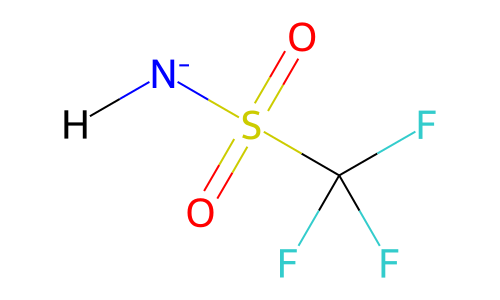

In [7]:
Molecule.from_mapped_smiles(list(uncovered_all_datasets["Industry Benchmark"].keys())[0])

In [14]:
old_new_ff = ForceField("generated_ff_old_improper.offxml")

In [16]:
old_new_ff.label_molecules(mol.to_topology())

[{'Constraints': ValenceDict({}),
  'vdW': ValenceDict(
    {(0,): <vdWType with smirks: [#6X4:1]  epsilon: 0.1088406109251 kilocalorie / mole  id: n16  rmin_half: 1.896698071741 angstrom  >,
     (1,): <vdWType with smirks: [#9:1]  epsilon: 0.061 kilocalorie / mole  id: n23  rmin_half: 1.75 angstrom  >,
     (2,): <vdWType with smirks: [#9:1]  epsilon: 0.061 kilocalorie / mole  id: n23  rmin_half: 1.75 angstrom  >,
     (3,): <vdWType with smirks: [#9:1]  epsilon: 0.061 kilocalorie / mole  id: n23  rmin_half: 1.75 angstrom  >,
     (4,): <vdWType with smirks: [#16:1]  epsilon: 0.25 kilocalorie / mole  id: n21  rmin_half: 2.0 angstrom  >,
     (5,): <vdWType with smirks: [#7:1]  epsilon: 0.1676915150424 kilocalorie / mole  id: n20  rmin_half: 1.799798315098 angstrom  >,
     (6,): <vdWType with smirks: [#8:1]  epsilon: 0.2102061007896 kilocalorie / mole  id: n17  rmin_half: 1.706036917087 angstrom  >,
     (7,): <vdWType with smirks: [#8:1]  epsilon: 0.2102061007896 kilocalorie / mole 

In [15]:
Interchange.from_smirnoff(force_field=old_new_ff, topology=mol.to_topology())

Interchange with 6 collections, non-periodic topology with 9 atoms.

In [9]:
mol = Molecule.from_mapped_smiles(list(uncovered_all_datasets["Industry Benchmark"].keys())[0], allow_undefined_stereo=True)
mol.generate_conformers(n_conformers=1)
vis = mol.visualize(backend="nglview")
vis.add_label(label_type="atomindex", color="black", attachment="middle-center")
vis


NGLWidget()

In [10]:
uncovered_all_datasets["Industry Benchmark"]

{'[H:9][N-:6][S:5](=[O:7])(=[O:8])[C:1]([F:2])([F:3])[F:4]': {'ProperTorsions': [(7,
    4,
    5,
    8),
   (6, 4, 5, 8),
   (0, 4, 5, 8)]}}

In [3]:
for name, SMILES in {
    "Train": smiles_data["train"], # Sanity check
    "TorsionNet": TNET_SMILES,
    "Biaryl": BIARYL_SMILES,
    "Test": smiles_data["test"],
    "Industry Benchmark": INDUSTRY_BENCHMARK_SMILES
    }.items():
    print(f"Checking {name} SMILES...")
    coverage_results = check_all_molecules_parameterisable_parallel_chunks(SMILES, new_ff)
    uncovered = [(smiles, is_covered) for smiles, is_covered in coverage_results if not is_covered]
    print(f"Uncovered: {len(uncovered)}/{len(SMILES)} ({len(uncovered) / len(SMILES) * 100:.2f}%)")
    if uncovered:
        print("Examples of uncovered molecules:")
        for smiles, _ in uncovered[:5]:
            print(smiles)

Checking Train SMILES...


NameError: name 'check_all_molecules_parameterisable_parallel_chunks' is not defined

In [186]:
[a.molecule_atom_index for a in mol.bonds[0].atoms]

[0, 5]

In [ ]:
len(smiles_data["train"])

23109

In [178]:
angles = get_all_mm_components(smiles_data["train"][:100], Angle)
angles_by_type = get_mm_components_by_specificity_by_type(angles, SPECIFICITY_LEVELS, cutoff_population=10)
summarise_all_types(angles_by_type)

Processing Components (parallel):   0%|          | 0/32 [00:00<?, ?it/s]


PicklingError: Can't pickle <class '__main__.SpecificityLevel'>: it's not the same object as __main__.SpecificityLevel

In [88]:
torsions = get_all_mm_components(smiles_data["train"][:100], ProperTorsion, unwanted_smirks=linear_torsion_smirks)
proper_torsions_by_type = get_mm_components_by_specificity_by_type(torsions, SPECIFICITY_LEVELS, cutoff_population=10)
summarise_all_types(proper_torsions_by_type)

Processing Mapped SMILES: 100%|██████████| 100/100 [00:00<00:00, 289.16it/s]


Filtering out unwanted SMIRKS: ['[*:1]-[*:2]#[*:3]-[*:4]', '[*:1]~[*:2]-[*:3]#[*:4]', '[*:1]~[*:2]=[#6,#7,#16,#15;X2:3]=[*:4]']


Filtering unwanted components: 100%|██████████| 10137/10137 [00:01<00:00, 7205.29it/s]

Filtered out 3 unwanted torsions.



Processing Components (parallel): 100%|██████████| 32/32 [00:01<00:00, 17.55it/s]


Total unique component types at specificity level 2: 157
Most common component types:
[#1X1:1]-[#6X4:2]-[#6X4:3]-[#1X1:4]: 822
[#1X1:1]-[#6X4:2]-[#6X4:3]-[#6X4:4]: 804
[#1X1:1]-[#6X3:2]:[#6X3:3]:[#6X3:4]: 790
[#6X3:1]:[#6X3:2]:[#6X3:3]:[#6X3:4]: 670
[#1X1:1]-[#6X4:2]-[#7X3:3]-[#6X4:4]: 344
[#1X1:1]-[#6X4:2]-[#6X4:3]-[#6X3:4]: 233
[#1X1:1]-[#6X4:2]-[#6X4:3]-[#7X3:4]: 224
[#1X1:1]-[#6X3:2]:[#6X3:3]-[#1X1:4]: 215
[#1X1:1]-[#6X4:2]-[#6X3:3]:[#6X3:4]: 177
[#1X1:1]-[#6X4:2]-[#7X3:3]-[#6X3:4]: 166
Total unique component types at specificity level 1: 31
Most common component types:
[!#1:1]~[#6X3:2]:[#6X3:3]~[!#1:4]: 130
[!#1:1]~[#6X3:2]-[#6X4:3]~[!#1:4]: 123
[!#1:1]~[#6X3:2]-[#6X3:3]~[!#1:4]: 87
[!#1:1]~[#6X3:2]-[#7X3:3]~[!#1:4]: 87
[!#1:1]~[#6X4:2]-[#6X4:3]~[!#1:4]: 67
[!#1:1]~[#6X3:2]-[#8X2:3]~[!#1:4]: 57
[!#1:1]~[#16X2:2]-[#6X3:3]~[!#1:4]: 53
[!#1:1]~[#6X3:2]=[#7X2:3]~[!#1:4]: 51
[!#1:1]~[#6X3:2]=[#6X3:3]~[!#1:4]: 44
[!#1:1]~[#6X4:2]-[#7X3:3]~[!#1:4]: 43
Total unique component types at spec

In [93]:
torsions = get_all_mm_components(smiles_data["train"][:100])
proper_torsions_by_type = get_proper_torsions_by_specificity_by_type(
    torsions,
    specificity_levels=SPECIFICITY_LEVELS,
    cutoff_population=10,
)
summarise_all_types(proper_torsions_by_type)

TypeError: get_all_mm_components() missing 1 required positional argument: 'component_type'

In [6]:
pprint(sorted(flatten_torsion_types(proper_torsions_by_type).items(), key=lambda item: item[1], reverse=True))

[('[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#6X4+0:4]', 189106),
 ('[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#1X1+0:4]', 168419),
 ('[#1X1+0:1]-[#6X3+0:2]:[#6X3+0:3]:[#6X3+0:4]', 165861),
 ('[#6X3+0:1]:[#6X3+0:2]:[#6X3+0:3]:[#6X3+0:4]', 139873),
 ('[#1X1+0:1]-[#6X3+0:2]:[#6X3+0:3]-[#1X1+0:4]', 48034),
 ('[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#6X3+0:4]', 46146),
 ('[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#7X3+0:4]', 44071),
 ('[#1X1+0:1]-[#6X4+0:2]-[#7X3+0:3]-[#6X4+0:4]', 43486),
 ('[#1X1+0:1]-[#6X4+0:2]-[#7X3+0:3]-[#6X3+0:4]', 42770),
 ('[#6X4+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#6X4+0:4]', 38281),
 ('[#1X1+0:1]-[#6X4+0:2]-[#6X3+0:3]:[#6X3+0:4]', 35832),
 ('[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#8X2+0:4]', 28887),
 ('[#6X3+0:1]-[#6X3+0:2]:[#6X3+0:3]:[#6X3+0:4]', 24517),
 ('[#1X1+0:1]-[#6X4+0:2]-[#6X3+0:3]=[#6X3+0:4]', 21612),
 ('[#6X3+0:1]:[#6X3+0:2]:[#6X3+0:3]-[#6X4+0:4]', 21287),
 ('[#6X3+0:1]:[#6X3+0:2]:[#6X3+0:3]-[#7X3+0:4]', 17569),
 ('[#1X1+0:1]-[#6X4+0:2]-[#6X3+0:3]=[#8X1+0:4]', 17419),
 ('[#6X3+0:1]-[#6X4+0:2]-[#

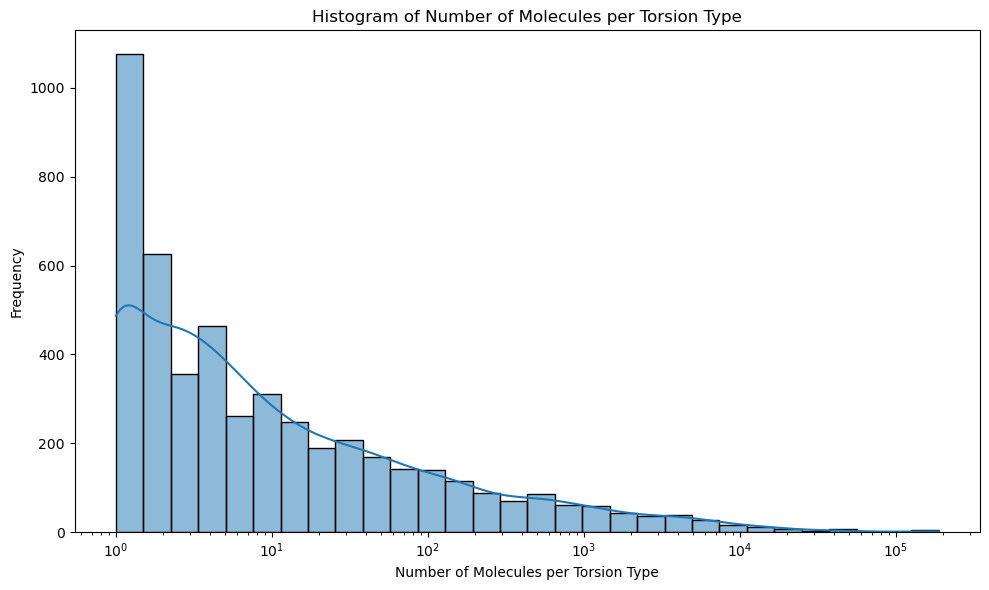

In [7]:
plot_histogram_of_n_mol_per_type(proper_torsions_by_type)

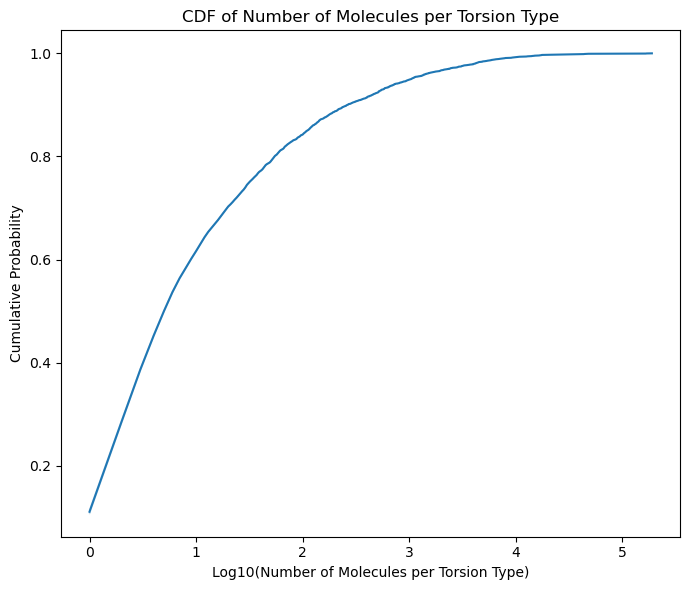

In [8]:
plot_cdf_of_n_mol_per_type(proper_torsions_by_type)

## Write Out to a Force Field

In [169]:
base_ff = ForceField("../input_ff/lj-sage-2-2-msm-0-expanded-torsions.offxml")
new_ff = add_types_to_ff(base_ff, angles_by_type, Angle)

Adding parameters for specificity 2: 100%|██████████| 81/81 [00:02<00:00, 35.18it/s]


In [170]:
new_ff.to_file("tmp.offxml")

In [94]:
base_ff = ForceField("openff-2.2.0.offxml")
new_ff = add_types_to_ff(base_ff, proper_torsions_by_type, component_class=ProperTorsion)
# Write out the new force field
# new_ff.to_file("tmp.offxml")

SMIRNOFFSpecError: Missing version while trying to construct <class 'openff.toolkit.typing.engines.smirnoff.parameters.ProperTorsionHandler'>. 0.3 SMIRNOFF spec requires each parameter section to have its own version.

In [4]:
new_ff = ForceField("../output_ff/spice2_linearised_harmonics_minibatch_systematic_tor_types_2_2_levels_fixed.offxml")

## Check if we can parameterise the test set...

In [5]:
uncovered_torsions = {}
for name, SMILES in {
    "Train": smiles_data["train"], # Sanity check
    "TorsionNet": TNET_SMILES,
    "Biaryl": BIARYL_SMILES,
    "Test": smiles_data["test"],
    "Industry Benchmark": INDUSTRY_BENCHMARK_SMILES
    }.items():
    print(f"Checking {name} SMILES...")
    coverage_results = check_all_molecules_torsions_fully_covered(SMILES, new_ff)
    uncovered_torsions[name] = [(smiles, indices) for smiles, is_covered, indices in coverage_results if not is_covered]
    covered_count = sum(1 for _, is_covered, _ in coverage_results if is_covered)
    print(f"Covered: {covered_count}/{len(SMILES)} ({covered_count / len(SMILES) * 100:.2f}%)")

Checking Train SMILES...


Checking Torsions Coverage: 100%|██████████| 23109/23109 [30:44<00:00, 12.53it/s]


Covered: 23109/23109 (100.00%)
Checking TorsionNet SMILES...


Checking Torsions Coverage: 100%|██████████| 500/500 [00:35<00:00, 14.21it/s]


Covered: 500/500 (100.00%)
Checking Biaryl SMILES...


...

Covered: 88/88 (100.00%)
Checking Test SMILES...


Checking Torsions Coverage: 100%|██████████| 1217/1217 [01:32<00:00, 13.21it/s]


Covered: 1213/1217 (99.67%)
Checking Industry Benchmark SMILES...


Checking Torsions Coverage: 100%|██████████| 9662/9662 [13:40<00:00, 11.78it/s]

Covered: 9662/9662 (100.00%)


In [23]:
uncovered_torsions["Industry Benchmark"]

['[H:26][C:1]#[N+:19][c:10]1[c:3]([c:2]([c:4]([c:12]([c:6]1[H:31])[S:24](=[O:21])(=[O:22])[c:13]2[c:5]([c:8]3[c:11]([c:14]([c:7]2[H:32])[Cl:25])[O:23][C:15]4=[C:9]3[C:16]([N:20]([C:18]([C:17]4([H:35])[H:36])([H:37])[H:38])[H:39])([H:33])[H:34])[H:30])[H:29])[H:27])[H:28]']

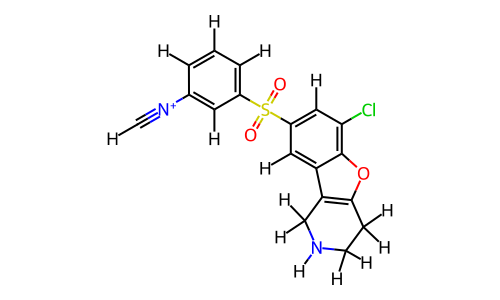

In [25]:
Molecule.from_mapped_smiles(uncovered_torsions["Industry Benchmark"][0], allow_undefined_stereo=True)

In [ ]:
imgs = []

for smiles, unassigned_torsion in uncovered_torsions["Industry Benchmark"]:
    img = show_molecule_with_atom_indices(smiles, unassigned_torsion)
    imgs.append(img)

ValueError: too many values to unpack (expected 2)

In [53]:
# res = check_all_molecules_torsions_fully_covered(smiles_data["test"], new_ff)
# res = check_all_molecules_torsions_fully_covered(TNET_SMILES, new_ff)
res = check_all_molecules_torsions_fully_covered(BIARYL_SMILES, new_ff)
# res = check_all_molecules_torsions_fully_covered(list(INDUSTRY_BENCHMARK_SMILES), new_ff)

# Summarise results
covered_count = sum(1 for _, is_covered, _ in res if is_covered)
print(f"Percentage of molecules with all torsions covered: {covered_count / len(res) * 100:.2f}% of {len(res)} molecules")

# Draw all of the uncovered torsions
imgs = []
uncovered_torsions = []
for smiles, is_covered, unassigned in res:
    if not is_covered:
        for unassigned_torsion in unassigned:
            uncovered_torsions.append((smiles, unassigned_torsion))

for smiles, unassigned_torsion in uncovered_torsions:
    img = show_molecule_with_atom_indices(smiles, unassigned_torsion)
    imgs.append(img)

Checking Torsions Coverage: 100%|██████████| 88/88 [00:02<00:00, 29.50it/s]


Percentage of molecules with all torsions covered: 86.36% of 88 molecules


In [38]:
# Draw all of the uncovered torsions
imgs = []
uncovered_torsions = []
for smiles, is_covered, unassigned in res:
    if not is_covered:
        for unassigned_torsion in unassigned:
            uncovered_torsions.append((smiles, unassigned_torsion))

for smiles, unassigned_torsion in uncovered_torsions:
    img = show_molecule_with_atom_indices(smiles, unassigned_torsion)
    imgs.append(img)

In [39]:
uncovered_torsions

[('[H:13][c:1]1[c:2]([c:4]([c:6]([c:5]([c:3]1[H:15])[H:17])[C:7]2=[N:9][O:12][C:8](=[N+:11]2[H:19])[N-:10][H:18])[H:16])[H:14]',
  (11, 7, 9, 17)),
 ('[H:13][c:1]1[c:2]([c:4]([c:6]([c:5]([c:3]1[H:15])[H:17])[C:7]2=[N:9][O:12][C:8](=[N+:11]2[H:19])[N-:10][H:18])[H:16])[H:14]',
  (10, 7, 9, 17))]

In [40]:
len(imgs)

2

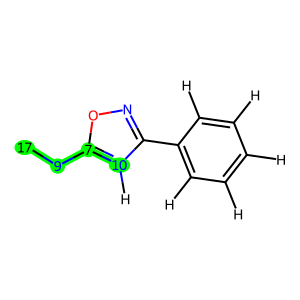

In [43]:
imgs[1]

In [37]:
uncovered_torsions

[('[H:42][c:24]1[c:6]([c:3]([c:19]([c:2]([c:7]1[H:30])[N:1]([H:26])[S+2:9]([c:10]2[c:18]([c:16]([c:15]([c:14]([c:11]2[O:12][C:13]([H:31])([H:32])[H:33])[H:34])[H:35])[Br:17])[H:36])([O-:8])[O-:25])[H:37])[N:20]3[C:5](=[O:23])[C:22]([C:21]([C:4]3([H:27])[H:28])([H:38])[H:39])([H:40])[H:41])[H:29]',
  (10, 9, 8, 24)),
 ('[H:42][c:24]1[c:6]([c:3]([c:19]([c:2]([c:7]1[H:30])[N:1]([H:26])[S+2:9]([c:10]2[c:18]([c:16]([c:15]([c:14]([c:11]2[O:12][C:13]([H:31])([H:32])[H:33])[H:34])[H:35])[Br:17])[H:36])([O-:8])[O-:25])[H:37])[N:20]3[C:5](=[O:23])[C:22]([C:21]([C:4]3([H:27])[H:28])([H:38])[H:39])([H:40])[H:41])[H:29]',
  (0, 8, 9, 10)),
 ('[H:42][c:24]1[c:6]([c:3]([c:19]([c:2]([c:7]1[H:30])[N:1]([H:26])[S+2:9]([c:10]2[c:18]([c:16]([c:15]([c:14]([c:11]2[O:12][C:13]([H:31])([H:32])[H:33])[H:34])[H:35])[Br:17])[H:36])([O-:8])[O-:25])[H:37])[N:20]3[C:5](=[O:23])[C:22]([C:21]([C:4]3([H:27])[H:28])([H:38])[H:39])([H:40])[H:41])[H:29]',
  (7, 8, 9, 17)),
 ('[H:42][c:24]1[c:6]([c:3]([c:19]([c:2]([c:7]1[

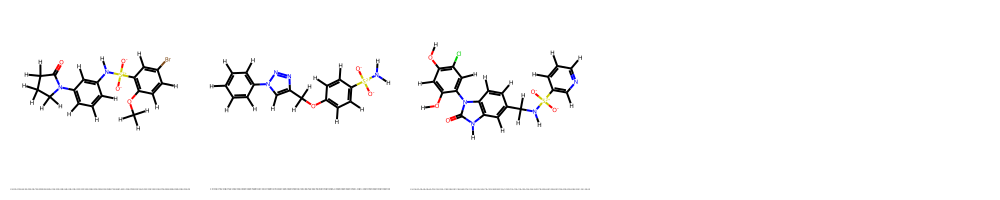

In [42]:
imgs

In [296]:
uncovered_torsions[16]

('[H:13][C-:5]([S:11](=[O:1])(=[O:2])[C:9]([H:23])([H:24])[H:25])[S:12](=[O:3])(=[O:4])[N+:10]([C:6]([H:14])([H:15])[H:16])([C:7]([H:17])([H:18])[H:19])[C:8]([H:20])([H:21])[H:22]',
 (9, 11, 4, 12))

In [38]:
len(uncovered_torsions)

36

In [39]:
uncovered_smiles = set([smiles for smiles, _ in uncovered_torsions])
len(uncovered_smiles)

3

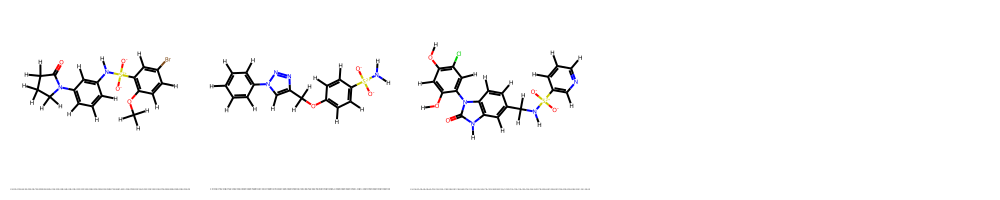

In [43]:
# Draw all of the uncovered smiles on a single image
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from PIL import Image

def draw_uncovered_smiles(uncovered_smiles: set[str]) -> Image:
    """
    Draw all uncovered smiles on a single image.
    
    Args:
        uncovered_smiles (set[str]): A set of uncovered SMILES strings.
    
    Returns:
        Image: A PIL Image containing the drawn molecules.
    """
    mols = [Molecule.from_mapped_smiles(smiles, allow_undefined_stereo=True).to_rdkit() for smiles in uncovered_smiles]
    img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=[f"{i+1}: {smiles}" for i, smiles in enumerate(uncovered_smiles)])
    return img

draw_uncovered_smiles(uncovered_smiles)

In [ ]:
# Check coverage of torsionnet500, rowley biaryl, and industry benchmark.


ModuleNotFoundError: No module named 'yammbs._base'

In [305]:
len(set([smiles for smiles, _ in uncovered_torsions]))

7

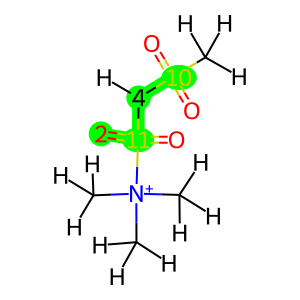

In [303]:
imgs[30]

In [ ]:

from concurrent.futures import ProcessPoolExecutor
from tqdm.contrib.concurrent import process_map
from functools import partial



# Check how much of the test set we can parameterise with this very specific force field
# check_smiles_ff_new = partial(check_can_parameterise, new_ff)
check_smiles_ff_new = partial(check_can_parameterise, base_ff)

can_parameterise = process_map(
    check_smiles_ff_new,
    smiles_data["test"][:100],
    max_workers=None,  # Use all available cores
    chunksize=10,      # Adjust as needed for performance
    desc="Parameterising test set"
)

In [172]:
tp = check_torsions_fully_covered(
    smiles_data["test"][0],
    new_ff
)

In [140]:

# Get the percentage of each type of result
print(f"Success: {can_parameterise.count('Success') / len(can_parameterise) * 100:.2f}%")
print(f"Torsion Error: {can_parameterise.count('Torsion Error') / len(can_parameterise) * 100:.2f}%")
print(f"Other Error: {can_parameterise.count('Other Error') / len(can_parameterise) * 100:.2f}%")

Success: 98.00%
Torsion Error: 0.00%
Other Error: 2.00%


In [ ]:
# Get the percentage of each type of result
print(f"Success: {can_parameterise.count('Success') / len(can_parameterise) * 100:.2f}%")
print(f"Torsion Error: {can_parameterise.count('Torsion Error') / len(can_parameterise) * 100:.2f}%")
print(f"Other Error: {can_parameterise.count('Other Error') / len(can_parameterise) * 100:.2f}%")

In [ ]:
# Get the percentage of each type of result
print(f"Success: {can_parameterise.count('Success') / len(can_parameterise) * 100:.2f}%")
print(f"Torsion Error: {can_parameterise.count('Torsion Error') / len(can_parameterise) * 100:.2f}%")
print(f"Other Error: {can_parameterise.count('Other Error') / len(can_parameterise) * 100:.2f}%")

Success: 94.00%
Torsion Error: 4.00%
Other Error: 2.00%


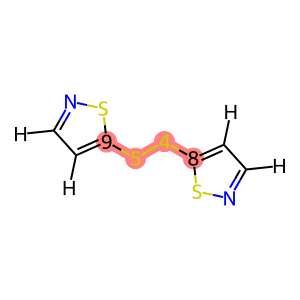

In [137]:
smiles = "[H:15][C:11]1=[C:9]([S:3][N:1]=[C:7]1[H:13])[S:5][S:6][C:10]2=[C:12]([C:8](=[N:2][S:4]2)[H:14])[H:16]"
highlight_indices = (8,4,5,9)
img = show_molecule_with_atom_indices(smiles, highlight_indices)
img

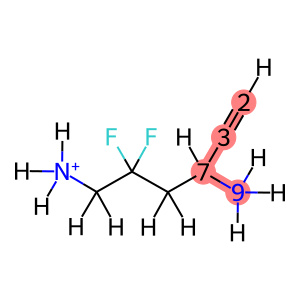

In [134]:
smiles = "[H:11][C:3]#[C:4][C:8]([H:16])([C:5]([H:12])([H:13])[C:6]([C:7]([H:14])([H:15])[N+:9]([H:17])([H:18])[H:19])([F:1])[F:2])[N+:10]([H:20])([H:21])[H:22]"
highlight_indices = (2,3,7,9)
img = show_molecule_with_atom_indices(smiles, highlight_indices)
img

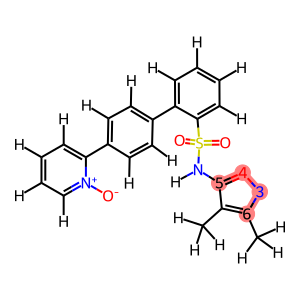

In [136]:
smiles = "[H:31][c:9]1[c:10]([c:17]([c:23]([c:22]([c:16]1[H:38])[c:20]2[c:12]([c:14]([c:21]([c:15]([c:13]2[H:35])[H:37])[c:25]3[c:19]([c:11]([c:18]([c:24]([n+:27]3[O-:3])[H:42])[H:40])[H:33])[H:41])[H:36])[H:34])[S:30](=[O:1])(=[O:2])[N:26]([H:43])[C:6]4=[O+:5][N-:4][C:7](=[C:8]4[C:29]([H:47])([H:48])[H:49])[C:28]([H:44])([H:45])[H:46])[H:39])[H:32]"
highlight_atoms = (5,4,3,6)
img = show_molecule_with_atom_indices(smiles, highlight_atoms)
img

<>:1: SyntaxWarning: invalid escape sequence '\['
<>:1: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_890931/392513653.py:1: SyntaxWarning: invalid escape sequence '\['
  smiles = "[O:1]=[C:6](/[C:9](=[C:10]([C:11](=[C:12](/[C:19]([C:21]([C:18](/[C:8](=[C:7](\[C:15]([C:5]#[C:3][C:2]#[C:4][C:14]([H:30])([H:31])[H:32])([H:33])[H:34])[H:23])[H:24])([H:41])[H:42])([H:47])[H:48])([H:43])[H:44])[H:28])/[H:27])\[H:26])[H:25])[N:13]([C:20]([C:22]([C:16]([H:35])([H:36])[H:37])([C:17]([H:38])([H:39])[H:40])[H:49])([H:45])[H:46])[H:29]"


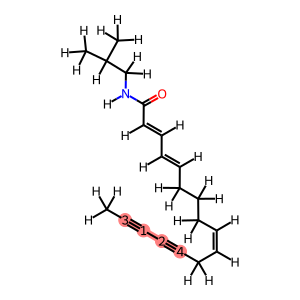

In [135]:
smiles = "[O:1]=[C:6](/[C:9](=[C:10]([C:11](=[C:12](/[C:19]([C:21]([C:18](/[C:8](=[C:7](\[C:15]([C:5]#[C:3][C:2]#[C:4][C:14]([H:30])([H:31])[H:32])([H:33])[H:34])[H:23])[H:24])([H:41])[H:42])([H:47])[H:48])([H:43])[H:44])[H:28])/[H:27])\[H:26])[H:25])[N:13]([C:20]([C:22]([C:16]([H:35])([H:36])[H:37])([C:17]([H:38])([H:39])[H:40])[H:49])([H:45])[H:46])[H:29]"
highlight_indices = (3,1,2,4)  # Indices of the atoms to highlight
show_molecule_with_atom_indices(smiles, highlight_indices)

In [ ]:
smiles = "[O:1]=[C:6](/[C:9](=[C:10]([C:11](=[C:12](/[C:19]([C:21]([C:18](/[C:8](=[C:7](\[C:15]([C:5]#[C:3][C:2]#[C:4][C:14]([H:30])([H:31])[H:32])([H:33])[H:34])[H:23])[H:24])([H:41])[H:42])([H:47])[H:48])([H:43])[H:44])[H:28])/[H:27])\[H:26])[H:25])[N:13]([C:20]([C:22]([C:16]([H:35])([H:36])[H:37])([C:17]([H:38])([H:39])[H:40])[H:49])([H:45])[H:46])[H:29]"
highlight_indices = (3,1,2,4)  # Indices of the atoms to highlight
show_molecule_with_atom_indices(smiles, highlight_indices)

<>:1: SyntaxWarning: invalid escape sequence '\['
<>:1: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_890931/392513653.py:1: SyntaxWarning: invalid escape sequence '\['
  smiles = "[O:1]=[C:6](/[C:9](=[C:10]([C:11](=[C:12](/[C:19]([C:21]([C:18](/[C:8](=[C:7](\[C:15]([C:5]#[C:3][C:2]#[C:4][C:14]([H:30])([H:31])[H:32])([H:33])[H:34])[H:23])[H:24])([H:41])[H:42])([H:47])[H:48])([H:43])[H:44])[H:28])/[H:27])\[H:26])[H:25])[N:13]([C:20]([C:22]([C:16]([H:35])([H:36])[H:37])([C:17]([H:38])([H:39])[H:40])[H:49])([H:45])[H:46])[H:29]"


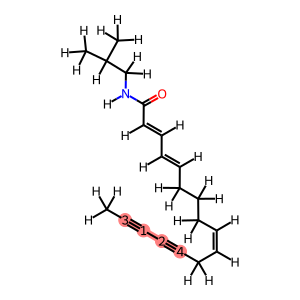

In [131]:
smiles = "[O:1]=[C:6](/[C:9](=[C:10]([C:11](=[C:12](/[C:19]([C:21]([C:18](/[C:8](=[C:7](\[C:15]([C:5]#[C:3][C:2]#[C:4][C:14]([H:30])([H:31])[H:32])([H:33])[H:34])[H:23])[H:24])([H:41])[H:42])([H:47])[H:48])([H:43])[H:44])[H:28])/[H:27])\[H:26])[H:25])[N:13]([C:20]([C:22]([C:16]([H:35])([H:36])[H:37])([C:17]([H:38])([H:39])[H:40])[H:49])([H:45])[H:46])[H:29]"
highlight_indices = (3,1,2,4)  # Indices of the atoms to highlight
show_molecule_with_atom_indices(smiles, highlight_indices)

In [122]:
v = mol.visualize()

In [115]:
smiles = "[O:1]=[C:6](/[C:9](=[C:10]([C:11](=[C:12](/[C:19]([C:21]([C:18](/[C:8](=[C:7](\[C:15]([C:5]#[C:3][C:2]#[C:4][C:14]([H:30])([H:31])[H:32])([H:33])[H:34])[H:23])[H:24])([H:41])[H:42])([H:47])[H:48])([H:43])[H:44])[H:28])/[H:27])\[H:26])[H:25])[N:13]([C:20]([C:22]([C:16]([H:35])([H:36])[H:37])([C:17]([H:38])([H:39])[H:40])[H:49])([H:45])[H:46])[H:29]"
mol = Molecule.from_mapped_smiles(smiles, allow_undefined_stereo=True)
mol.generate_conformers(n_conformers=1)
view = mol.visualize(backend="nglview")
view.add_label(label_type="atomindex", color="black", attachment="middle-center")
view


<>:1: SyntaxWarning: invalid escape sequence '\['
<>:1: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_890931/1263703598.py:1: SyntaxWarning: invalid escape sequence '\['
  smiles = "[O:1]=[C:6](/[C:9](=[C:10]([C:11](=[C:12](/[C:19]([C:21]([C:18](/[C:8](=[C:7](\[C:15]([C:5]#[C:3][C:2]#[C:4][C:14]([H:30])([H:31])[H:32])([H:33])[H:34])[H:23])[H:24])([H:41])[H:42])([H:47])[H:48])([H:43])[H:44])[H:28])/[H:27])\[H:26])[H:25])[N:13]([C:20]([C:22]([C:16]([H:35])([H:36])[H:37])([C:17]([H:38])([H:39])[H:40])[H:49])([H:45])[H:46])[H:29]"


NGLWidget()

In [46]:
torsions = get_all_proper_torsions(smiles_data["train"][:100])
proper_torsions_by_type = get_proper_torsions_by_specificity_by_type(
    torsions,
    specificity_levels=SPECIFICTY_LEVELS,
    cutoff_population=10
)
summarise_all_types(proper_torsions_by_type)

Processing Torsions: 100%|██████████| 1460/1460 [00:00<00:00, 36820.90it/s]


Total unique torsion types at specificity level 1: 705
Most common torsion types:
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#1X1+0:4]: 822
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#6X4+0:4]: 804
[#1X1+0:1]-[#6X3+0:2]:[#6X3+0:3]:[#6X3+0:4]: 790
[#6X3+0:1]:[#6X3+0:2]:[#6X3+0:3]:[#6X3+0:4]: 670
[#1X1+0:1]-[#6X4+0:2]-[#7X3+0:3]-[#6X4+0:4]: 344
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#6X3+0:4]: 233
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#7X3+0:4]: 216
[#1X1+0:1]-[#6X3+0:2]:[#6X3+0:3]-[#1X1+0:4]: 215
[#1X1+0:1]-[#6X4+0:2]-[#6X3+0:3]:[#6X3+0:4]: 177
[#1X1+0:1]-[#6X4+0:2]-[#7X3+0:3]-[#6X3+0:4]: 162
Total unique torsion types at specificity level 0: 494
Most common torsion types:
[#1X1+0:1]~[#6X4+0:2]-[#6X3+0:3]~[#7X2+0:4]: 16
[#6X3+0:1]~[#6X3+0:2]-[#8X2+0:3]~[#6X3+0:4]: 15
[#6X3+0:1]~[#6X3+0:2]-[#6X3+0:3]~[#7X2+0:4]: 12
[#7X2+0:1]~[#6X3+0:2]-[#6X3+0:3]~[#7X3+0:4]: 10
[#6X3+0:1]~[#6X3+0:2]-[#16X2+0:3]~[#6X4+0:4]: 10
[#6X3+0:1]~[#6X3+0:2]-[#16X4+0:3]~[#8X1+0:4]: 10
[#1X1+0:1]~[#6X4+0:2]-[#16X3+0:3]~[#8X1+0:4]: 9
[#6X4+0:

In [37]:
torsions = get_all_proper_torsions(smiles_data["train"][:100])
proper_torsions_by_type = get_proper_torsions_by_specificity_by_type(
    torsions,
    specificity_levels=SPECIFICTY_LEVELS,
    cutoff_population=10
)
summarise_all_types(proper_torsions_by_type)

Processing Torsions: 100%|██████████| 1460/1460 [00:00<00:00, 62023.29it/s]

Total unique torsion types at specificity level 1: 706
Most common torsion types:
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#1X1+0:4]: 822
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#6X4+0:4]: 804
[#1X1+0:1]-[#6X3+0:2]:[#6X3+0:3]:[#6X3+0:4]: 790
[#6X3+0:1]:[#6X3+0:2]:[#6X3+0:3]:[#6X3+0:4]: 670
[#1X1+0:1]-[#6X4+0:2]-[#7X3+0:3]-[#6X4+0:4]: 344
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#6X3+0:4]: 233
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#7X3+0:4]: 216
[#1X1+0:1]-[#6X3+0:2]:[#6X3+0:3]-[#1X1+0:4]: 215
[#1X1+0:1]-[#6X4+0:2]-[#6X3+0:3]:[#6X3+0:4]: 177
[#1X1+0:1]-[#6X4+0:2]-[#7X3+0:3]-[#6X3+0:4]: 162
Total unique torsion types at specificity level 0: 495
Most common torsion types:
[#1X1+0:1]~[#6X4+0:2]-[#6X3+0:3]~[#7X2+0:4]: 16
[#6X3+0:1]~[#6X3+0:2]-[#8X2+0:3]~[#6X3+0:4]: 15
[#6X3+0:1]~[#6X3+0:2]-[#6X3+0:3]~[#7X2+0:4]: 12
[#7X2+0:1]~[#6X3+0:2]-[#6X3+0:3]~[#7X3+0:4]: 10
[#6X3+0:1]~[#6X3+0:2]-[#16X2+0:3]~[#6X4+0:4]: 10
[#6X3+0:1]~[#6X3+0:2]-[#16X4+0:3]~[#8X1+0:4]: 10
[#1X1+0:1]~[#6X4+0:2]-[#16X3+0:3]~[#8X1+0:4]: 9
[#6X4+0:

In [30]:
torsions = get_all_proper_torsions(smiles_data["train"][:1000])
proper_torsions_by_type = get_proper_torsions_by_specificity_by_type(
    torsions,
    specificity_levels=SPECIFICTY_LEVELS,
    cutoff_population=10
)
summarise_all_types(proper_torsions_by_type)

Processing Torsions: 100%|██████████| 1416/1416 [00:00<00:00, 52207.12it/s]


Total unique torsion types at specificity level 1: 886
Most common torsion types:
[!#1X40:1]-[#6X40:2]-[#6X40:3]-[#1X10:4]: 8351
[!#1X30:1]:[#6X30:2]:[#6X30:3]-[#1X10:4]: 8333
[#1X10:1]-[#6X40:2]-[#6X40:3]-[#1X10:4]: 7927
[!#1X30:1]:[#6X30:2]:[#6X30:3]:[!#1X30:4]: 7064
[!#1X30:1]-[#6X40:2]-[#6X40:3]-[#1X10:4]: 4244
[!#1X40:1]-[#7X30:2]-[#6X40:3]-[#1X10:4]: 2550
[#1X10:1]-[#6X30:2]:[#6X30:3]-[#1X10:4]: 2353
[!#1X30:1]-[#6X30:2]:[#6X30:3]:[!#1X30:4]: 2149
[!#1X30:1]:[#6X30:2]-[#6X40:3]-[#1X10:4]: 1952
[!#1X30:1]-[#7X30:2]-[#6X40:3]-[#1X10:4]: 1874
Total unique torsion types at specificity level 0: 596
Most common torsion types:
[#6X40:1]-[#8X20:2]-[#6X30:3]=[#7X20:4]: 9
[#6X30:1]-[#16X20:2]-[#6X30:3]:[#7X20:4]: 9
[#1X10:1]-[#6X40:2]-[#7X30:3]-[#7X41:4]: 9
[#6X30:1]-[#8X20:2]-[#6X30:3]:[#7X20:4]: 9
[#7X20:1]-[#7X30:2]-[#6X30:3]:[#7X20:4]: 9
[#7X20:1]-[#7X30:2]-[#7X20:3]=[#7X20:4]: 9
[#1X10:1]-[#6X40:2]-[#6X30:3]-[#7X2-1:4]: 9
[#6X40:1]-[#6X30:2]=[#7X20:3]-[#6X40:4]: 8
[#1X10:1]-[#7X30:2]-

In [24]:
torsions = get_all_proper_torsions(smiles_data["train"][:1000])
proper_torsions_by_type = get_proper_torsions_by_type(torsions, specificity=SmirksSpecificity.GENERALISED)
torsion_type_counts = get_torsion_type_num(proper_torsions_by_type)
summarise_all_types(torsion_type_counts)

Processing Torsions: 100%|██████████| 103511/103511 [00:01<00:00, 94035.98it/s]

Total unique torsion types: 64
Most common torsion types:
[*:1]~[#6X3+0:2]~[#6X3+0:3]~[*:4]: 37752
[*:1]~[#6X4+0:2]~[#6X4+0:3]~[*:4]: 26394
[*:1]~[#6X3+0:2]~[#6X4+0:3]~[*:4]: 10806
[*:1]~[#6X4+0:2]~[#7X3+0:3]~[*:4]: 8206
[*:1]~[#6X3+0:2]~[#7X3+0:3]~[*:4]: 7512
[*:1]~[#6X3+0:2]~[#7X2+0:3]~[*:4]: 3176
[*:1]~[#6X4+0:2]~[#8X2+0:3]~[*:4]: 2077
[*:1]~[#6X3+0:2]~[#8X2+0:3]~[*:4]: 1656
[*:1]~[#16X2+0:2]~[#6X3+0:3]~[*:4]: 892
[*:1]~[#6X4+0:2]~[#7X41:3]~[*:4]: 799
% of torsion types with count < 5: 29.69%
% of torsion types with count = 1: 3.12%


In [11]:
summarise_all_types(torsion_type_counts)

Total unique torsion types: 1543
Most common torsion types:
[#1X1+0:1]-[#6X3+0:2]:[#6X3+0:3]:[#6X3+0:4]: 8333
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#6X4+0:4]: 8257
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#1X1+0:4]: 7927
[#6X3+0:1]:[#6X3+0:2]:[#6X3+0:3]:[#6X3+0:4]: 7064
[#1X1+0:1]-[#6X4+0:2]-[#7X3+0:3]-[#6X4+0:4]: 2449
[#1X1+0:1]-[#6X3+0:2]:[#6X3+0:3]-[#1X1+0:4]: 2353
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#6X3+0:4]: 2227
[#1X1+0:1]-[#6X4+0:2]-[#6X4+0:3]-[#7X3+0:4]: 2004
[#1X1+0:1]-[#6X4+0:2]-[#6X3+0:3]:[#6X3+0:4]: 1952
[#1X1+0:1]-[#6X4+0:2]-[#7X3+0:3]-[#6X3+0:4]: 1838
% of torsion types with count < 5: 53.27%
% of torsion types with count = 1: 25.41%


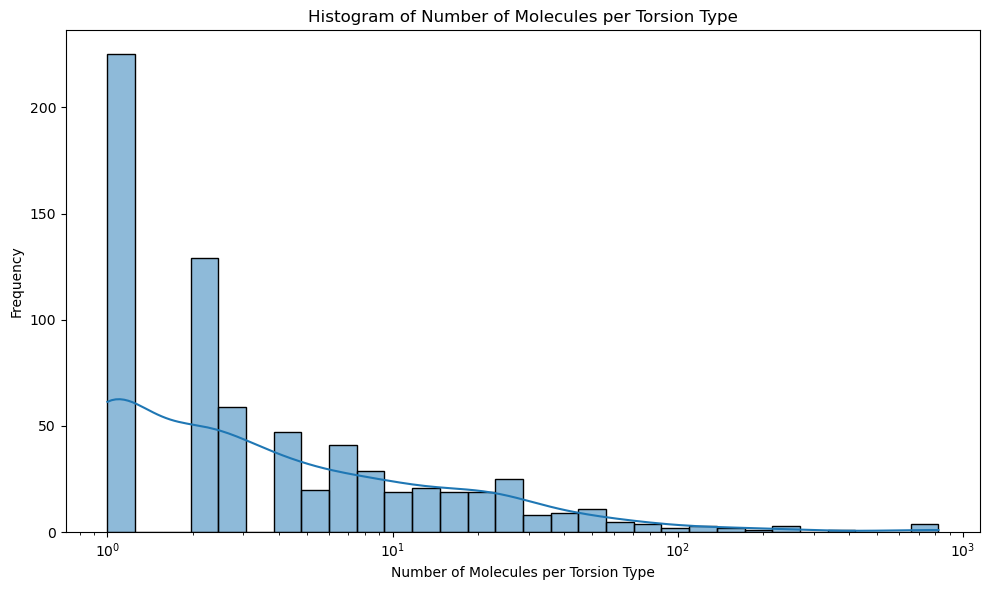

In [9]:
plot_histogram_of_n_mol_per_type(proper_torsions_by_type)

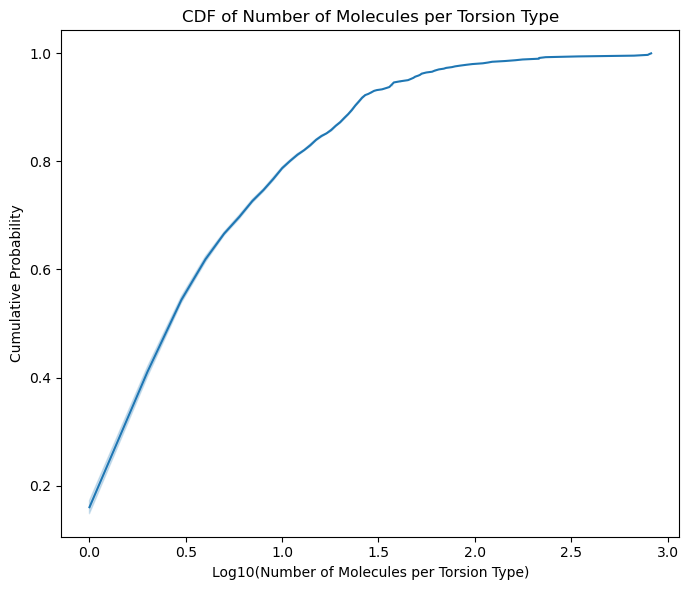

In [21]:
plot_cdf_of_n_mol_per_type(proper_torsions_by_type)

In [ ]:
sorted(torsion_type_counts.items(), key=lambda item: item[1], reverse=True)

In [6]:
pprint(sorted(torsion_type_counts.items(), key=lambda item: item[1], reverse=True))

AttributeError: 'list' object has no attribute 'items'

In [ ]:
summarise_all_types(torsion_type_counts)

In [ ]:
plot_cdf_of_n_mol_per_type(torsion_type_counts)

In [ ]:
plot_histogram_of_n_mol_per_type(torsion_type_counts)

In [ ]:
mol = Molecule.from_mapped_smiles("[F:1][S:3][S:4][F:2]")
mol.to_smiles(mapped=True)

In [ ]:
ff = ForceField("openff-2.0.0.offxml")

In [ ]:
ff.create_openmm_system(Molecule.from_mapped_smiles("[At:1][c:10]1[c:5]([H:27])[c:7]([H:29])[c:12]2[c:14]([c:9]1[H:31])[C@:22]([N+:24]1([H:49])[C:20]([H:43])([H:44])[C:18]([H:39])([H:40])[N+:23]([C:17]([C:15]([H:32])([H:33])[H:34])([H:37])[H:38])([H:48])[C:19]([H:41])([H:42])[C:21]1([H:45])[H:46])([H:47])[C:16]([H:35])([H:36])[c:13]1[c:8]([H:30])[c:4]([H:26])[c:3]([H:25])[c:6]([H:28])[c:11]1[S:2]2").to_topology())

In [ ]:
all_types = get_all_torsion_types(smiles_data["train"])

In [ ]:
summarise_all_types(all_types)

In [ ]:
summarise_all_types(all_types)

In [ ]:
plot_cdf_of_n_mol_per_type(all_types)

In [ ]:
plot_histogram_of_n_mol_per_type(all_types)

In [ ]:
import pprint
pprint.pprint(all_types)

In [ ]:
ff_new = add_types_to_ff(ForceField("../input_ff/lj-sage-2-2-msm-0-expanded-torsions.offxml"), all_types)
ff_new.to_file("../input_ff/lj-sage-2-2-msm-0-expanded-torsions-systematic-tor-types-1.offxml")

In [ ]:
ff_new = ForceField("../input_ff/lj-sage-2-2-msm-0-expanded-torsions-systematic-tor-types-1.offxml")
check_can_parameterise = [check_smiles_ff_new(smiles) for smiles in tqdm(smiles_data["test"][:100])]

In [ ]:
print(f"% Parameterised: {sum(check_can_parameterise) / len(check_can_parameterise) * 100:.2f}%")

In [ ]:
print(f"% Parameterised: {sum(1 for res in check_can_parameterise if res == 'Success') / len(check_can_parameterise) * 100:.2f}%")
print(f"% Torsion Error: {sum(1 for res in check_can_parameterise if res == 'Torsion Error') / len(check_can_parameterise) * 100:.2f}%")
print(f"% Other Error: {sum(1 for res in check_can_parameterise if res == 'Other Error') / len(check_can_parameterise) * 100:.2f}%")

In [ ]:
check_can_parameterise

In [ ]:
from concurrent.futures import ProcessPoolExecutor
from tqdm.contrib.concurrent import process_map
from functools import partial


# Check how much of the test set we can parameterise with this very specific force field

ff_new = ForceField("../input_ff/lj-sage-2-2-msm-0-expanded-torsions-systematic-tor-types-1.offxml")

check_smiles_ff_new = partial(check_can_parameterise, ff_new)


can_parameterise = process_map(
    check_smiles_ff_new,
    smiles_data["test"][:150],
    max_workers=None,  # Use all available cores
    chunksize=10,      # Adjust as needed for performance
    desc="Parameterising test set"
)

In [ ]:
Molecule.from_smiles("P(Cl)(Cl)(Cl)Cl")

In [ ]:
Molecule.from_mapped_smiles("[Cl:1][c:10]1[c:5]([H:27])[c:7]([H:29])[c:12]2[c:14]([c:9]1[H:31])[C@:22]([N+:24]1([H:49])[C:20]([H:43])([H:44])[C:18]([H:39])([H:40])[N+:23]([C:17]([C:15]([H:32])([H:33])[H:34])([H:37])[H:38])([H:48])[C:19]([H:41])([H:42])[C:21]1([H:45])[H:46])([H:47])[C:16]([H:35])([H:36])[c:13]1[c:8]([H:30])[c:4]([H:26])[c:3]([H:25])[c:6]([H:28])[c:11]1[S:2]2")

In [ ]:
get_torsion_types("[F:1][S:3][S:4][F:2]")

In [ ]:
mol = Molecule.from_mapped_smiles("[F:1][S:3][S:4][F:2]")


In [ ]:
mol.find_rotatable_bonds()

In [ ]:
ff_new.label_molecules(Molecule.from_mapped_smiles("[F:1][S:3][S:4][F:2]").to_topology())

In [ ]:
smirks_from_dihedral(Molecule.from_mapped_smiles("[F:1][S:3][S:4][F:2]"), (0,2,3,1))

In [ ]:
'[#9X1+0:1]-[#16X2+0:2]-[#16X2+0:3]-[#9X1+0:4]' in all_types

In [ ]:
"[F:1][S:3][S:4][F:2]" in smiles_data["test"]

In [ ]:
with open("torsion_types.pkl", "rb") as f:
    all_types = pkl.load(f)

In [ ]:
plot_all_types(all_types)

In [ ]:
all_types

In [ ]:
+smiles:str) -> set[str]:
    mapped_smiles = mol.to_smiles(mapped=True)
    torsion_indices = get_proper_torsion_idxs(mapped_smiles)
    return {smirks_from_dihedral(mapped_smiles, idx) for idx in torsion_indices}

In [ ]:
mol.to_smiles(mapped=True)

In [ ]:
get_proper_torsion_idxs(mol)

In [ ]:
SMILES = '[H:13][c:1]1[c:2]([c:3]([c:4]([c:5]([c:6]1[H:17])[H:16])[c:7]2[c:8]([c:9]([c:10]([c:11]([c:12]2[H:22])[H:21])[H:20])[H:19])[H:18])[H:15])[H:14]'
SMILES = "C1=CC=C(C=C1)C2=CC=CC=C2"
mol = Molecule.from_smiles(SMILES)
ff = ForceField("openff-2.2.0.offxml")

In [ ]:
smirks_from_dihedral(SMILES, (4, 3, 6, 14))

In [ ]:
mol

In [ ]:
mol[list(mol.propers)]

In [ ]:
len(mol.torsions)

In [ ]:
mol.torsions

In [ ]:
mol.atom_index(list(mol.propers)[0][0])

In [ ]:
dir(list(mol.propers)[0][0])

In [ ]:
ff.label_molecules(mol.to_topology())[0]["ProperTorsions"]

In [ ]:
len(ff.label_molecules(mol.to_topology())[0]["ProperTorsions"])

In [ ]:
len(ff.label_molecules(mol.to_topology())[0]["ImproperTorsions"])

In [ ]:
smiles_data["train"]